In [1]:
import os

# Ensure a stable working directory (project root) regardless of where this
# notebook is launched from, so relative paths like data/processed/... and
# outputs/... resolve consistently. Idempotent: walks up until a directory
# containing both data/ and notebooks/ is found (the project root).
while not (os.path.isdir("data") and os.path.isdir("notebooks")):
    parent = os.path.dirname(os.getcwd())
    if parent == os.getcwd():
        raise RuntimeError("Could not locate project root (expected data/ and notebooks/ folders)")
    os.chdir(parent)

os.makedirs("outputs/figures", exist_ok=True)
os.makedirs("outputs/tables", exist_ok=True)
print("Working directory:", os.getcwd())
print("Output folders ready")


Working directory: C:\Users\GRACE TECH\Desktop\energy_poverty_africa
Output folders ready


In [2]:
# LIBRARIES 
# Data manipulation
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Lasso, Ridge, ElasticNet
from sklearn.svm import SVR
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Display
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully")

All libraries imported successfully


In [3]:
#  LOAD DATA

# The data contains MEPI scores + all 34 driver variables established theoritically

df = pd.read_csv('data/processed/mepi_with_drivers.csv')

print(f"Shape              : {df.shape}")
print(f"Countries          : {df['Country Name'].nunique()}")
print(f"Years              : {df['Time'].nunique()} "
      f"({int(df['Time'].min())}–{int(df['Time'].max())})")
print(f"\nColumn names:")
print(df.columns.tolist())


Shape              : (1242, 44)
Countries          : 54
Years              : 23 (2000–2022)

Column names:
['Country Name', 'Time', 'D1_electricity_access', 'D2_affordability_efficiency', 'D3_reliability', 'D4_clean_cooking', 'D5_sustainability', 'deprivation_score_c', 'is_poor', 'MEPI', 'GDP growth (annual %)', 'GDP (current US$)', 'Final consumption expenditure (% of GDP)', 'Inflation, consumer prices (annual %)', 'External debt stocks (% of GNI)', 'Debt service (PPG and IMF only, % of exports of goods, services and primary income)', 'Net primary income (BoP, current US$)', 'Fuel exports (% of merchandise exports)', 'Fuel imports (% of merchandise imports)', 'Oil rents (% of GDP)', 'Natural gas rents (% of GDP)', 'Adjusted savings: energy depletion (% of GNI)', 'Adjusted savings: natural resources depletion (% of GNI)', 'Adjusted savings: particulate emission damage (% of GNI)', 'Government Effectiveness: Estimate', 'Population, total', 'Population growth (annual %)', 'Population den

# DATASET OVERVIEW NOTE
### Dataset: 
          mepi_with_drivers.csv
### Source : 
           World Bank World Development Indicators (WDI)
### Period : 
            2000–2022 (23 years)
### Countries: 
            54 Sub-Saharan African countries
### Observations: 
                1,242 country-year observations (54 × 23 = 1,242 — balanced panel)

## COLUMN STRUCTURE (44 columns total):
#
## ID variables (2):
   - Country Name, Time

### MEPI components (8):
   - D1_electricity_access        : dimension score — electricity access
  - D2_affordability_efficiency  : dimension score — affordability & efficiency
   - D3_reliability               : dimension score — reliability
   - D4_clean_cooking             : dimension score — clean cooking
   - D5_sustainability            : dimension score — sustainability
   - deprivation_score_c          : weighted deprivation score (0–1)
   - is_poor                      : binary poverty classification (k = 1/3)
   - MEPI                         : dependent variable — censored deprivation
                                   score (c_i if poor, 0 if not poor)

### Driver variables (34) — candidate independent variables:
   Economic & income        (9) : GDP growth, GDP, final consumption,
                                  inflation, external debt, debt service,
                                  net primary income, fuel exports, fuel imports
   Natural resource & fiscal(5) : oil rents, gas rents, energy depletion,
                                  NR depletion, particulate emission damage
   Institutional            (1) : government effectiveness
   Demographic & spatial    (7) : population total, population growth,
                                 population density, rural population %,
                                 rural population growth, urban population %,
                                 urban population growth
   Environmental            (3) : CO2 per capita, CO2 % change from 1990,
                                  freshwater resources per capita
   Structural & energy mix  (9) : fossil fuel consumption, alternative energy,
                                  electricity from coal, hydro, gas, oil,
                                  nuclear, non-hydro renewables, energy use p.c.

### MODELLING NOTE:
  - MEPI is treated as a continuous dependent variable
  - MEPI = 0 for non-poor observations (c_i < k = 1/3)
   - MEPI = c_i for poor observations (c_i >= k = 1/3)
   - Country heterogeneity handled by the algorithm (no explicit fixed effects)
   - Panel econometric model (FE/RE) to be run separately in Stata




In [4]:
#  VARIABLE DEFINITIONS
# Dependent variable
target = 'MEPI'

# ID variables — not used in modelling
id_vars = ['Country Name', 'Time']

# Dimension score columns — not used as drivers
dim_cols = [
    'D1_electricity_access',
    'D2_affordability_efficiency',
    'D3_reliability',
    'D4_clean_cooking',
    'D5_sustainability'
]

# Other MEPI-related columns — excluded from drivers
mepi_cols = ['deprivation_score_c', 'is_poor']

# ── DRIVER VARIABLES ──────────────────────────────────────────────────────────
economic_drivers = [
    'GDP growth (annual %)',
    'GDP (current US$)',
    'Final consumption expenditure (% of GDP)',
    'Inflation, consumer prices (annual %)',
    'External debt stocks (% of GNI)',
    'Debt service (PPG and IMF only, % of exports of goods, services and primary income)',
    'Net primary income (BoP, current US$)',
    'Fuel exports (% of merchandise exports)',
    'Fuel imports (% of merchandise imports)',
]

resource_drivers = [
    'Oil rents (% of GDP)',
    'Natural gas rents (% of GDP)',
    'Adjusted savings: energy depletion (% of GNI)',
    'Adjusted savings: natural resources depletion (% of GNI)',
    'Adjusted savings: particulate emission damage (% of GNI)',
]

governance_drivers = [
    'Government Effectiveness: Estimate',
]

demographic_drivers = [
    'Population, total',
    'Population growth (annual %)',
    'Population density (people per sq. km of land area)',
    'Rural population (% of total population)',
    'Rural population growth (annual %)',
    'Urban population (% of total population)',
    'Urban population growth (annual %)',
]

environmental_drivers = [
    'Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)',
    'Carbon dioxide (CO2) emissions (total) excluding LULUCF (% change from 1990)',
    'Renewable internal freshwater resources per capita (cubic meters)',
]

structural_drivers = [
    'Fossil fuel energy consumption (% of total)',
    'Alternative and nuclear energy (% of total energy use)',
    'Electricity production from coal sources (% of total)',
    'Electricity production from hydroelectric sources (% of total)',
    'Electricity production from natural gas sources (% of total)',
    'Electricity production from oil sources (% of total)',
    'Electricity production from nuclear sources (% of total)',
    'Electricity production from renewable sources, excluding hydroelectric (% of total)',
    'Energy use (kg of oil equivalent per capita)',
]

driver_vars = (
    economic_drivers   +
    resource_drivers   +
    governance_drivers +
    demographic_drivers +
    environmental_drivers +
    structural_drivers
)

# Validate all driver variables exist in df
missing = [v for v in driver_vars if v not in df.columns]
if missing:
    print(f"WARNING — missing from df: {missing}")
else:
    print(f"Target variable    : {target}")
    print(f"Driver variables   : {len(driver_vars)}")
    print(f"All variables found in df")

Target variable    : MEPI
Driver variables   : 34
All variables found in df


## Exploratory Data Analysis 

In [5]:
#  BASIC DATA INSPECTION 

print("=" * 60)
print("FIRST 5 ROWS")
print("=" * 60)
display(df.head())

print("\n" + "=" * 60)
print("DATA TYPES")
print("=" * 60)
print(df.dtypes)

print("\n" + "=" * 60)
print("MISSING VALUES")
print("=" * 60)
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing count' : missing,
    'Missing %'     : missing_pct
})
missing_df = missing_df[missing_df['Missing count'] > 0]
if len(missing_df) == 0:
    print("No missing values found — data is clean")
else:
    print(missing_df.sort_values('Missing %', ascending=False))

FIRST 5 ROWS


,Country Name,Time,D1_electricity_access,D2_affordability_efficiency,D3_reliability,D4_clean_cooking,D5_sustainability,deprivation_score_c,is_poor,MEPI,...,Renewable internal freshwater resources per capita (cubic meters),Fossil fuel energy consumption (% of total),Alternative and nuclear energy (% of total energy use),Electricity production from coal sources (% of total),Electricity production from hydroelectric sources (% of total),Electricity production from natural gas sources (% of total),Electricity production from oil sources (% of total),Electricity production from nuclear sources (% of total),"Electricity production from renewable sources, excluding hydroelectric (% of total)",Energy use (kg of oil equivalent per capita)
0,Angola,2022,0.480961,0.205683,0.528473,0.551667,0.226096,0.466667,1,0.398576,...,4153.216769,0.000000,6.55,8.033157,70.424412,10.892597,16.221531,0.098538,5.12964,423.122518
1,Benin,2022,0.423000,0.546323,0.802961,0.941333,0.233670,0.766667,1,0.589457,...,748.573658,0.000000,0.05,8.033157,38.094979,73.026973,23.576424,0.098538,5.12964,375.820984
2,Botswana,2022,0.345333,0.431536,0.448093,0.406000,0.240172,0.633333,1,0.374227,...,983.650096,0.000000,0.08,96.193093,38.094979,15.114333,3.571429,0.098538,5.12964,1165.149687
3,Burkina Faso,2022,0.722000,0.318259,0.581989,0.773333,0.170671,0.566667,1,0.513251,...,555.332485,0.000000,0.18,8.033157,4.913122,15.114333,85.979629,0.098538,5.12964,312.929086
4,Burundi,2022,0.747000,0.558665,0.837244,0.998667,0.103998,0.800000,1,0.649115,...,755.193060,11.120924,0.48,8.033157,38.094979,15.114333,37.074181,0.098538,5.12964,447.479810



DATA TYPES
Country Name                                                                            object
Time                                                                                     int64
D1_electricity_access                                                                  float64
D2_affordability_efficiency                                                            float64
D3_reliability                                                                         float64
D4_clean_cooking                                                                       float64
D5_sustainability                                                                      float64
deprivation_score_c                                                                    float64
is_poor                                                                                  int64
MEPI                                                                                   float64
GDP growth (annual %)                 

MEPI DESCRIPTIVE STATISTICS
count    1242.0000
mean        0.5089
std         0.1169
min         0.1258
25%         0.4560
50%         0.5350
75%         0.5961
max         0.6997
Name: MEPI, dtype: float64

Zero MEPI (non-poor) : 0 obs (0.0%)
Non-zero MEPI (poor) : 1242 obs (100.0%)


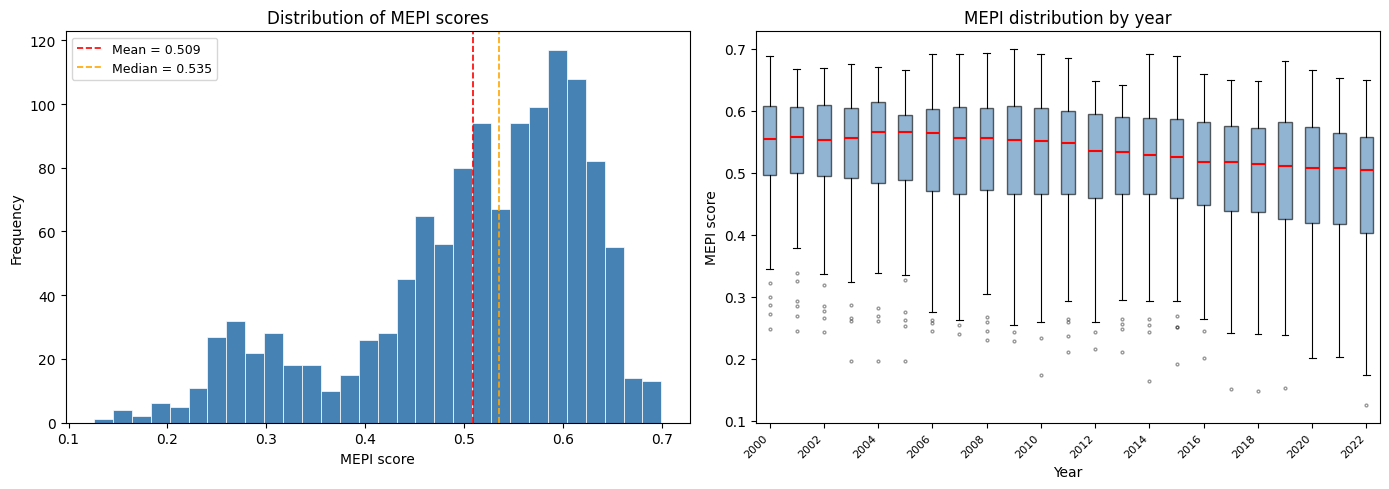

Saved: outputs/figures/01_mepi_distribution.png


In [6]:
# ── MEPI DISTRIBUTION ─────────────────────────────────────────────────────────



print("=" * 60)
print("MEPI DESCRIPTIVE STATISTICS")
print("=" * 60)
print(df['MEPI'].describe().round(4))

print(f"\nZero MEPI (non-poor) : "
      f"{(df['MEPI'] == 0).sum()} obs "
      f"({(df['MEPI'] == 0).mean()*100:.1f}%)")
print(f"Non-zero MEPI (poor) : "
      f"{(df['MEPI'] > 0).sum()} obs "
      f"({(df['MEPI'] > 0).mean()*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['MEPI'], bins=30, color='steelblue',
             edgecolor='white', linewidth=0.5)
axes[0].axvline(df['MEPI'].mean(), color='red', linestyle='--',
                linewidth=1.2, label=f"Mean = {df['MEPI'].mean():.3f}")
axes[0].axvline(df['MEPI'].median(), color='orange', linestyle='--',
                linewidth=1.2, label=f"Median = {df['MEPI'].median():.3f}")
axes[0].set_xlabel('MEPI score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of MEPI scores')
axes[0].legend(fontsize=9)

# Boxplot by year — fix x-axis readability
yearly_data = [df[df['Time'] == yr]['MEPI'].values
               for yr in sorted(df['Time'].unique())]
years = sorted(df['Time'].unique())

axes[1].boxplot(yearly_data, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6),
                medianprops=dict(color='red', linewidth=1.5),
                flierprops=dict(marker='o', markersize=2, alpha=0.4),
                whiskerprops=dict(linewidth=0.8),
                capprops=dict(linewidth=0.8))

# Set x-axis ticks — show every other year to avoid crowding
tick_positions = list(range(1, len(years) + 1))
axes[1].set_xticks(tick_positions[::2])
axes[1].set_xticklabels([str(y) for y in years[::2]],
                         rotation=45, ha='right', fontsize=8)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('MEPI score')
axes[1].set_title('MEPI distribution by year')

plt.tight_layout()
plt.savefig('outputs/figures/01_mepi_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/figures/01_mepi_distribution.png")

TOP 10 MOST ENERGY POOR COUNTRIES
                 Country  Mean MEPI
                   Benin     0.6420
Central African Republic     0.6319
            Sierra Leone     0.6292
                    Togo     0.6246
                 Liberia     0.6225
                  Uganda     0.6222
                  Malawi     0.6210
                 Burundi     0.6157
                   Niger     0.6134
           Guinea-Bissau     0.6047

BOTTOM 10 LEAST ENERGY POOR COUNTRIES
         Country  Mean MEPI
           Libya     0.4283
          Angola     0.4236
         Morocco     0.3286
    South Africa     0.3267
           Gabon     0.3171
      Seychelles     0.3058
         Tunisia     0.2711
Egypt, Arab Rep.     0.2529
         Algeria     0.2519
       Mauritius     0.2007


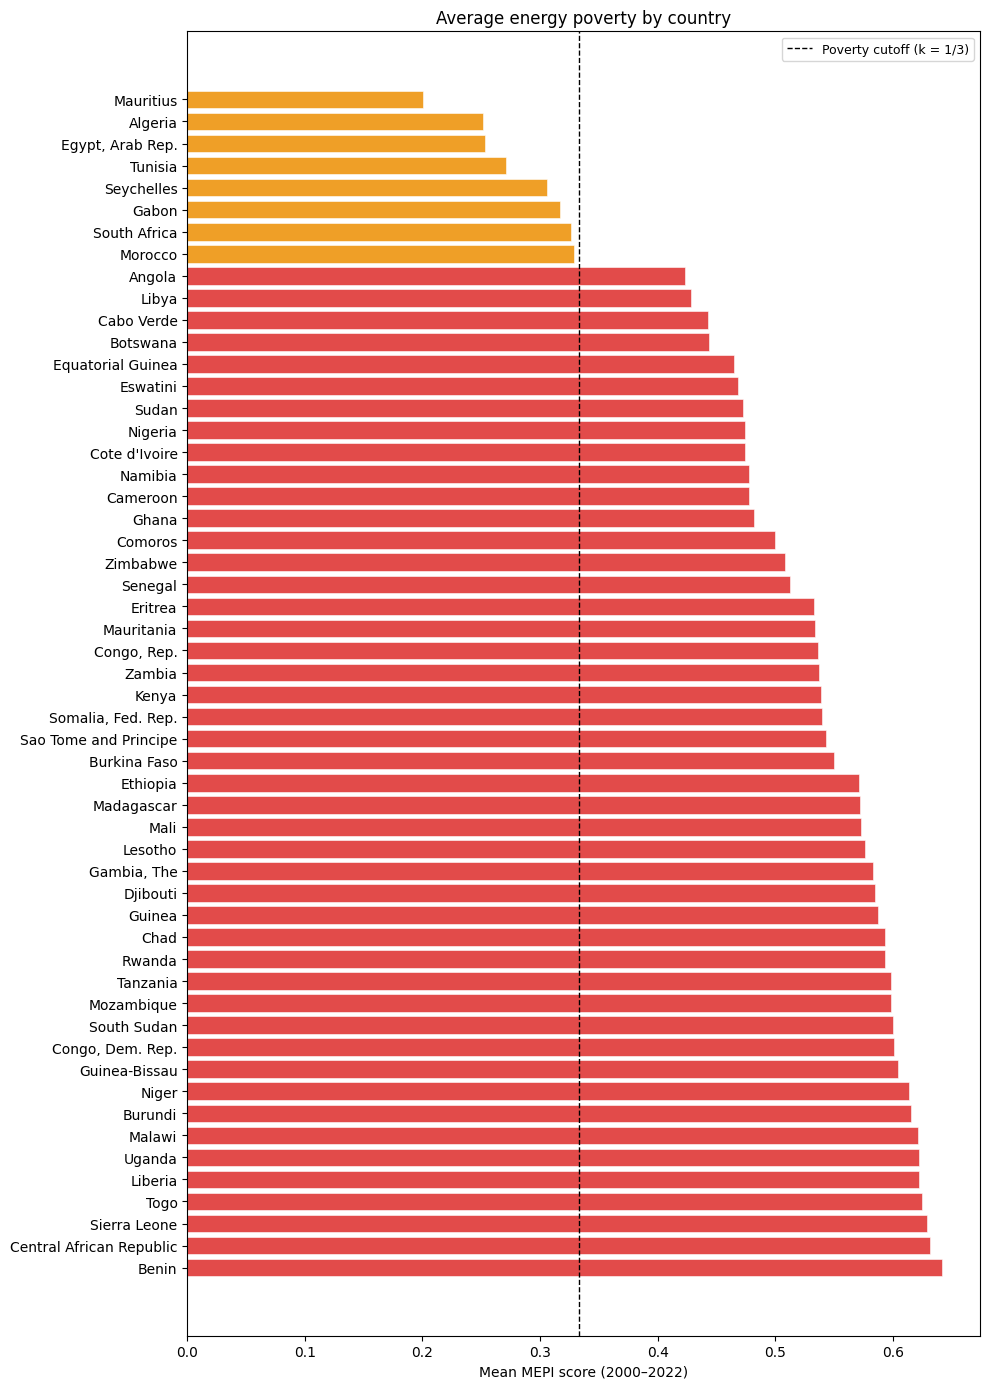

Saved: outputs/figures/02_mepi_by_country.png


In [7]:
# ── MEPI BY COUNTRY ───────────────────────────────────────────────────────────
# Ranks countries by their average MEPI score over the full period

country_mepi = (
    df.groupby('Country Name')['MEPI']
    .mean()
    .round(4)
    .sort_values(ascending=False)
    .reset_index()
)
country_mepi.columns = ['Country', 'Mean MEPI']

print("=" * 60)
print("TOP 10 MOST ENERGY POOR COUNTRIES")
print("=" * 60)
print(country_mepi.head(10).to_string(index=False))

print("\n" + "=" * 60)
print("BOTTOM 10 LEAST ENERGY POOR COUNTRIES")
print("=" * 60)
print(country_mepi.tail(10).to_string(index=False))

# Horizontal bar chart
fig, ax = plt.subplots(figsize=(10, 14))
colors = [
    '#E24B4A' if v >= 0.333 else
    '#EF9F27' if v >= 0.2  else
    '#1D9E75'
    for v in country_mepi['Mean MEPI']
]
ax.barh(country_mepi['Country'], country_mepi['Mean MEPI'],
        color=colors, edgecolor='white', linewidth=0.4)
ax.axvline(0.333, color='black', linestyle='--',
           linewidth=1, label='Poverty cutoff (k = 1/3)')
ax.set_xlabel('Mean MEPI score (2000–2022)')
ax.set_title('Average energy poverty by country')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('outputs/figures/02_mepi_by_country.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/figures/02_mepi_by_country.png")

MEPI TREND BY YEAR
 Year   Mean  Median    Std
 2000 0.5289  0.5544 0.1093
 2001 0.5300  0.5572 0.1097
 2002 0.5260  0.5527 0.1120
 2003 0.5263  0.5564 0.1159
 2004 0.5288  0.5658 0.1153
 2005 0.5203  0.5665 0.1125
 2006 0.5225  0.5638 0.1147
 2007 0.5225  0.5558 0.1166
 2008 0.5228  0.5568 0.1163
 2009 0.5212  0.5532 0.1175
 2010 0.5161  0.5521 0.1219
 2011 0.5116  0.5474 0.1179
 2012 0.5082  0.5351 0.1150
 2013 0.5055  0.5344 0.1139
 2014 0.5049  0.5282 0.1200
 2015 0.5047  0.5259 0.1190
 2016 0.4980  0.5177 0.1145
 2017 0.4912  0.5177 0.1179
 2018 0.4878  0.5141 0.1181
 2019 0.4862  0.5114 0.1205
 2020 0.4854  0.5085 0.1183
 2021 0.4828  0.5071 0.1166
 2022 0.4726  0.5049 0.1282


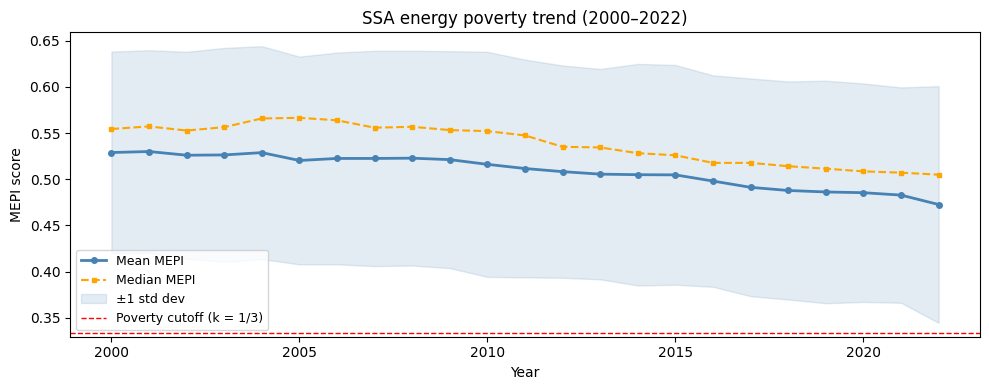

Saved: outputs/figures/03_mepi_trend.png


In [8]:
# ── MEPI TREND OVER TIME ──────────────────────────────────────────────────────
# Shows whether energy poverty across SSA is improving or worsening
# The shaded band shows how much variation exists across countries each year

yearly = (
    df.groupby('Time')['MEPI']
    .agg(['mean', 'median', 'std'])
    .round(4)
    .reset_index()
)
yearly.columns = ['Year', 'Mean', 'Median', 'Std']

print("=" * 60)
print("MEPI TREND BY YEAR")
print("=" * 60)
print(yearly.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(yearly['Year'], yearly['Mean'],
        color='steelblue', linewidth=2,
        marker='o', markersize=4, label='Mean MEPI')
ax.plot(yearly['Year'], yearly['Median'],
        color='orange', linewidth=1.5,
        linestyle='--', marker='s', markersize=3, label='Median MEPI')
ax.fill_between(
    yearly['Year'],
    yearly['Mean'] - yearly['Std'],
    yearly['Mean'] + yearly['Std'],
    alpha=0.15, color='steelblue', label='±1 std dev'
)
ax.axhline(0.333, color='red', linestyle='--',
           linewidth=1, label='Poverty cutoff (k = 1/3)')
ax.set_xlabel('Year')
ax.set_ylabel('MEPI score')
ax.set_title('SSA energy poverty trend (2000–2022)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('outputs/figures/03_mepi_trend.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/figures/03_mepi_trend.png")

DIMENSION SCORES — DESCRIPTIVE STATISTICS
       D1_electricity_access  D2_affordability_efficiency  D3_reliability  D4_clean_cooking  D5_sustainability
count              1242.0000                    1242.0000       1242.0000         1242.0000          1242.0000
mean                  0.5193                       0.4289          0.6246            0.7362             0.2353
std                   0.2560                       0.1577          0.1790            0.3206             0.1685
min                   0.0000                       0.0150          0.0522            0.0000             0.0189
25%                   0.3814                       0.3146          0.5305            0.5724             0.1001
50%                   0.5455                       0.4590          0.6254            0.8987             0.1804
75%                   0.7270                       0.5344          0.7561            0.9839             0.3602
max                   0.9783                       0.8484          0.9

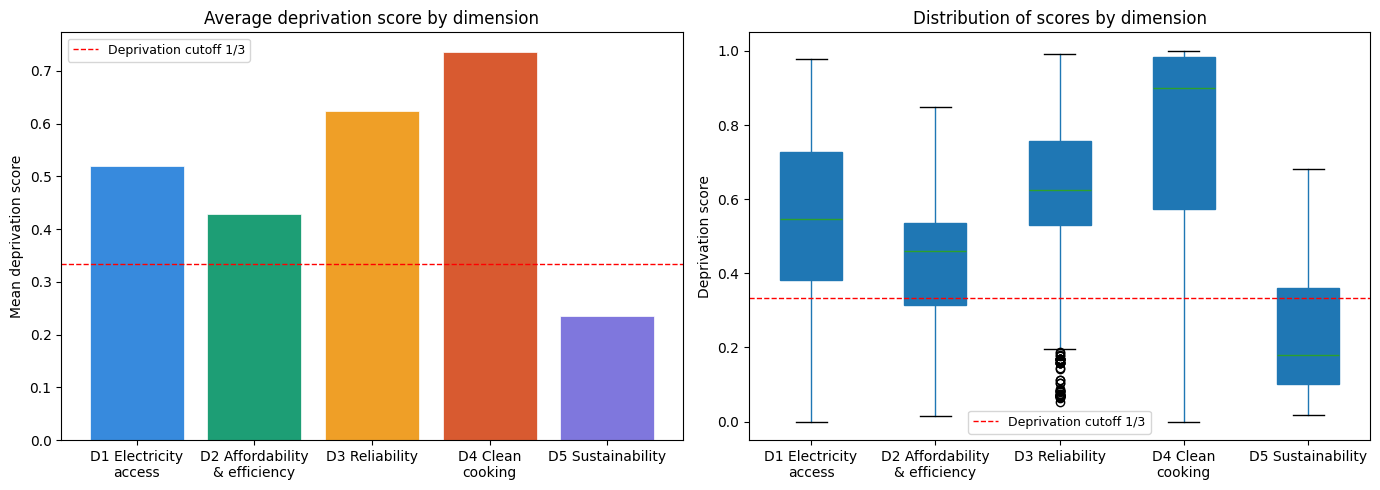

Saved: outputs/figures/04_dimension_scores.png


In [9]:
# ── DIMENSION SCORES COMPARISON ───────────────────────────────────────────────
# Shows which of the 5 MEPI dimensions has the highest average deprivation
# This tells you where energy poverty in SSA is most concentrated

dim_cols = [
    'D1_electricity_access',
    'D2_affordability_efficiency',
    'D3_reliability',
    'D4_clean_cooking',
    'D5_sustainability'
]

dim_labels = [
    'D1 Electricity\naccess',
    'D2 Affordability\n& efficiency',
    'D3 Reliability',
    'D4 Clean\ncooking',
    'D5 Sustainability'
]

print("=" * 60)
print("DIMENSION SCORES — DESCRIPTIVE STATISTICS")
print("=" * 60)
print(df[dim_cols].describe().round(4).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mean dimension scores bar chart
mean_dims = df[dim_cols].mean().values
colors_dim = ['#378ADD', '#1D9E75', '#EF9F27', '#D85A30', '#7F77DD']
axes[0].bar(dim_labels, mean_dims, color=colors_dim,
            edgecolor='white', linewidth=0.5)
axes[0].axhline(0.333, color='red', linestyle='--',
                linewidth=1, label='Deprivation cutoff 1/3')
axes[0].set_ylabel('Mean deprivation score')
axes[0].set_title('Average deprivation score by dimension')
axes[0].legend(fontsize=9)

# Boxplot
df[dim_cols].rename(
    columns=dict(zip(dim_cols, dim_labels))
).boxplot(ax=axes[1], grid=False, patch_artist=True)
axes[1].axhline(0.333, color='red', linestyle='--',
                linewidth=1, label='Deprivation cutoff 1/3')
axes[1].set_ylabel('Deprivation score')
axes[1].set_title('Distribution of scores by dimension')
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.savefig('outputs/figures/04_dimension_scores.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/figures/04_dimension_scores.png")

In [10]:
# ── DRIVER VARIABLES DESCRIPTIVE STATISTICS ───────────────────────────────────
# Summary statistics for all 34 driver variables
# Important for understanding the range and scale of your independent variables
# before modelling — helps interpret scaled coefficients later

driver_vars_list = [
    'GDP growth (annual %)',
    'GDP (current US$)',
    'Final consumption expenditure (% of GDP)',
    'Inflation, consumer prices (annual %)',
    'External debt stocks (% of GNI)',
    'Debt service (PPG and IMF only, % of exports of goods, services and primary income)',
    'Net primary income (BoP, current US$)',
    'Fuel exports (% of merchandise exports)',
    'Fuel imports (% of merchandise imports)',
    'Oil rents (% of GDP)',
    'Natural gas rents (% of GDP)',
    'Adjusted savings: energy depletion (% of GNI)',
    'Adjusted savings: natural resources depletion (% of GNI)',
    'Adjusted savings: particulate emission damage (% of GNI)',
    'Government Effectiveness: Estimate',
    'Population, total',
    'Population growth (annual %)',
    'Population density (people per sq. km of land area)',
    'Rural population (% of total population)',
    'Rural population growth (annual %)',
    'Urban population (% of total population)',
    'Urban population growth (annual %)',
    'Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)',
    'Carbon dioxide (CO2) emissions (total) excluding LULUCF (% change from 1990)',
    'Renewable internal freshwater resources per capita (cubic meters)',
    'Fossil fuel energy consumption (% of total)',
    'Alternative and nuclear energy (% of total energy use)',
    'Electricity production from coal sources (% of total)',
    'Electricity production from hydroelectric sources (% of total)',
    'Electricity production from natural gas sources (% of total)',
    'Electricity production from oil sources (% of total)',
    'Electricity production from nuclear sources (% of total)',
    'Electricity production from renewable sources, excluding hydroelectric (% of total)',
    'Energy use (kg of oil equivalent per capita)',
]

desc = df[driver_vars_list].describe().T.round(4)
desc = desc[['count', 'mean', 'std', 'min', '50%', 'max']]
desc.columns = ['N', 'Mean', 'Std Dev', 'Min', 'Median', 'Max']
desc.index.name = 'Variable'

print("=" * 60)
print("DRIVER VARIABLES — DESCRIPTIVE STATISTICS")
print("=" * 60)
display(desc)

desc.to_csv('outputs/tables/descriptive_statistics_drivers.csv')
print("\nSaved: outputs/tables/descriptive_statistics_drivers.csv")

DRIVER VARIABLES — DESCRIPTIVE STATISTICS


,N,Mean,Std Dev,Min,Median,Max
Variable,,,,,,
GDP growth (annual %),1242.0,4.046100e+00,6.226600e+00,-5.033850e+01,4.203000e+00,8.682670e+01
GDP (current US$),1242.0,3.616476e+10,7.689058e+10,7.595113e+07,1.116323e+10,5.741838e+11
Final consumption expenditure (% of GDP),1242.0,8.381230e+01,1.658130e+01,1.671300e+01,8.381230e+01,1.455170e+02
"Inflation, consumer prices (annual %)",1242.0,9.657200e+00,2.646600e+01,-1.685970e+01,5.832500e+00,5.572018e+02
External debt stocks (% of GNI),1242.0,5.823250e+01,5.831410e+01,2.321600e+00,4.908080e+01,6.104519e+02
"Debt service (PPG and IMF only, % of exports of goods, services and primary income)",1242.0,8.021600e+00,9.401600e+00,3.500000e-03,7.164500e+00,1.347220e+02
"Net primary income (BoP, current US$)",1242.0,-1.054202e+09,2.421032e+09,-2.552056e+10,-3.750693e+08,2.017000e+09
Fuel exports (% of merchandise exports),1242.0,1.546070e+01,2.641000e+01,0.000000e+00,1.554100e+00,9.965650e+01
Fuel imports (% of merchandise imports),1242.0,1.517760e+01,8.117800e+00,1.050000e-02,1.514700e+01,5.269600e+01



Saved: outputs/tables/descriptive_statistics_drivers.csv


CORRELATION WITH MEPI (sorted by absolute value)
Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)            -0.6023
Energy use (kg of oil equivalent per capita)                                          -0.5722
Rural population (% of total population)                                               0.5370
Urban population (% of total population)                                              -0.5370
Rural population growth (annual %)                                                     0.4997
Government Effectiveness: Estimate                                                    -0.4923
Adjusted savings: particulate emission damage (% of GNI)                               0.4604
Electricity production from natural gas sources (% of total)                          -0.4419
Fossil fuel energy consumption (% of total)                                           -0.4394
GDP (current US$)                                                                     -0.4325
Urban popul

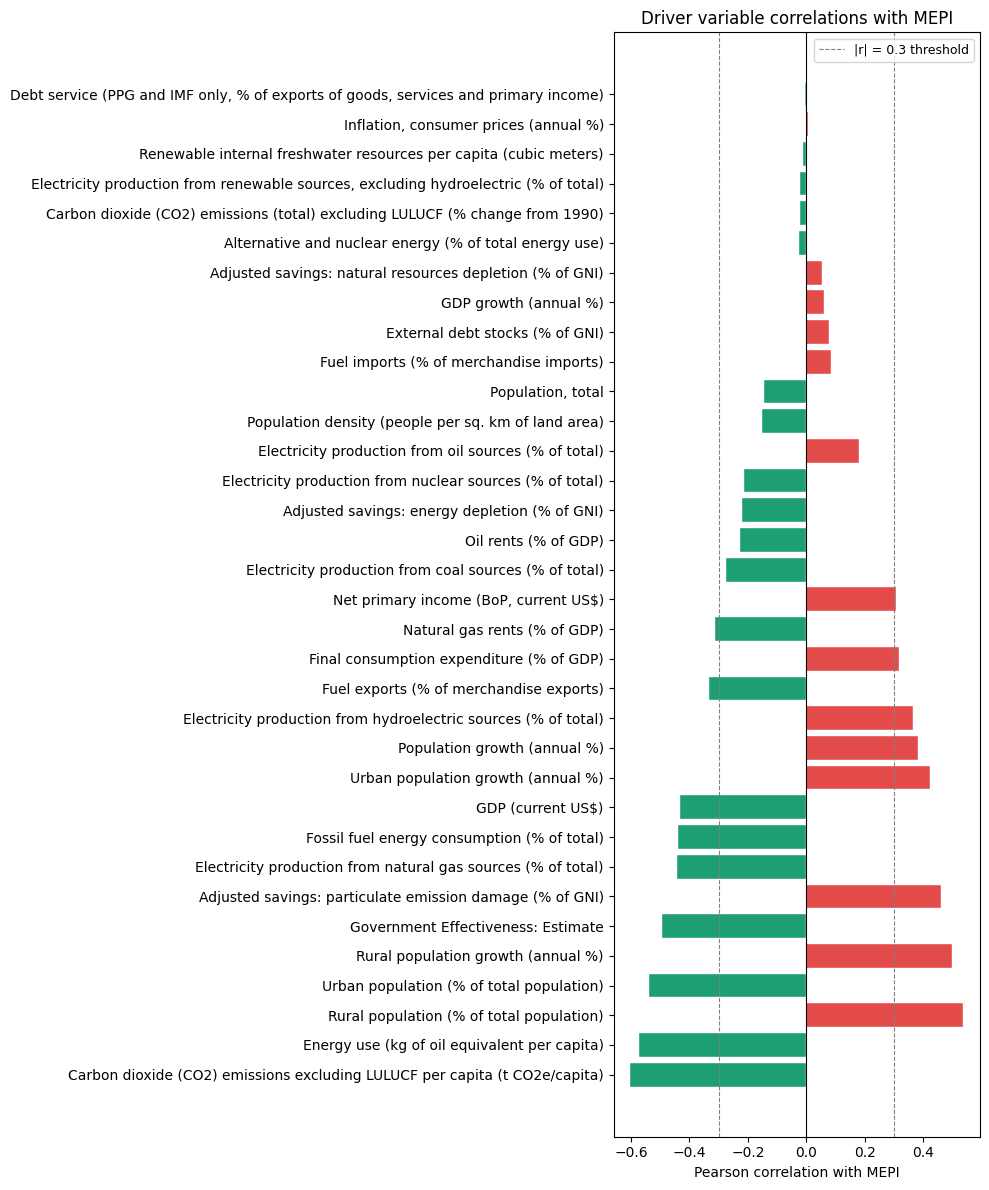

Saved: outputs/figures/05_correlation_with_mepi.png


In [11]:
# ── CORRELATION OF DRIVERS WITH MEPI ──────────────────────────────────────────
# Pearson correlation tells you the linear relationship between
# each driver variable and MEPI
# Positive correlation = higher driver value associated with more energy poverty
# Negative correlation = higher driver value associated with less energy poverty
# This is a first signal of which variables are likely to matter in the model

corr_mepi = (
    df[driver_vars_list + ['MEPI']]
    .corr()['MEPI']
    .drop('MEPI')
    .sort_values(key=abs, ascending=False)
    .round(4)
)

print("=" * 60)
print("CORRELATION WITH MEPI (sorted by absolute value)")
print("=" * 60)
print(corr_mepi.to_string())

fig, ax = plt.subplots(figsize=(10, 12))
colors = ['#E24B4A' if v > 0 else '#1D9E75'
          for v in corr_mepi.values]
ax.barh(corr_mepi.index, corr_mepi.values,
        color=colors, edgecolor='white', linewidth=0.3)
ax.axvline(0, color='black', linewidth=0.8)
ax.axvline(0.3, color='gray', linestyle='--',
           linewidth=0.8, label='|r| = 0.3 threshold')
ax.axvline(-0.3, color='gray', linestyle='--', linewidth=0.8)
ax.set_xlabel('Pearson correlation with MEPI')
ax.set_title('Driver variable correlations with MEPI')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('outputs/figures/05_correlation_with_mepi.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/figures/05_correlation_with_mepi.png")

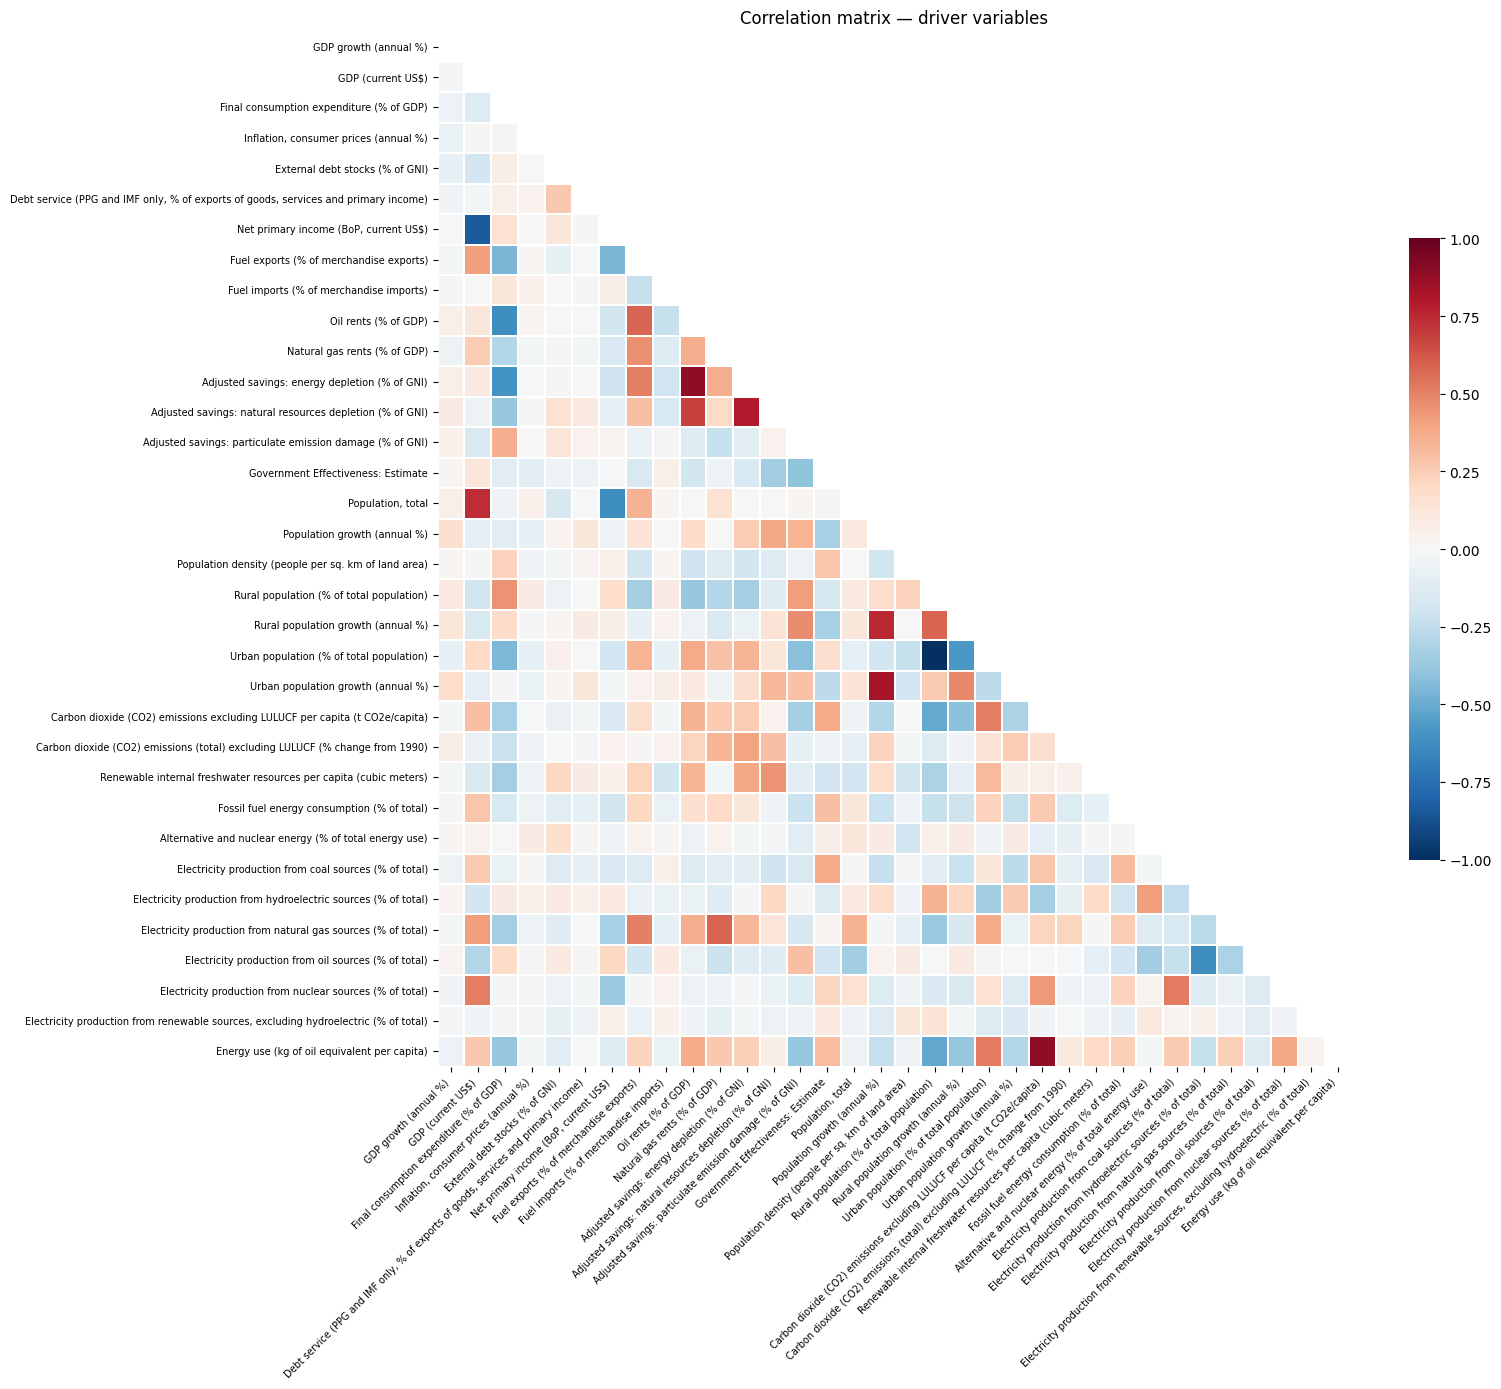

HIGH CORRELATIONS AMONG DRIVERS (|r| > 0.8)
                                                                Variable 1                                    Variable 2  Correlation
                                  Rural population (% of total population)      Urban population (% of total population)        -1.00
Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)  Energy use (kg of oil equivalent per capita)         0.89
                                                      Oil rents (% of GDP) Adjusted savings: energy depletion (% of GNI)         0.89
                                                         GDP (current US$)         Net primary income (BoP, current US$)        -0.84
                                              Population growth (annual %)            Urban population growth (annual %)         0.83

Total pairs flagged : 5
Note: RFE handles multicollinearity by design
but reviewing these pairs informs interpretation

Saved: outputs/figures/06_corre

In [12]:
# ── MULTICOLLINEARITY CHECK ───────────────────────────────────────────────────
# Before running RFE we need to check if any driver variables are
# highly correlated with each other (multicollinearity)
# Why does this matter? If two variables are almost identical
# (e.g. rural population % and urban population % sum to 100)
# the model cannot distinguish their individual effects
# We flag pairs with |r| > 0.8 as potentially problematic

corr_matrix = df[driver_vars_list].corr().round(2)

# Heatmap
fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.3,
    annot=False,
    ax=ax,
    cbar_kws={'shrink': 0.6}
)
ax.set_title('Correlation matrix — driver variables')
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.savefig('outputs/figures/06_correlation_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Flag high correlations
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        if abs(val) > 0.8:
            high_corr.append({
                'Variable 1' : corr_matrix.columns[i],
                'Variable 2' : corr_matrix.columns[j],
                'Correlation': round(val, 4)
            })

print("=" * 60)
print("HIGH CORRELATIONS AMONG DRIVERS (|r| > 0.8)")
print("=" * 60)
if high_corr:
    high_corr_df = (
        pd.DataFrame(high_corr)
        .sort_values('Correlation', key=abs, ascending=False)
    )
    print(high_corr_df.to_string(index=False))
    print(f"\nTotal pairs flagged : {len(high_corr_df)}")
    print("Note: RFE handles multicollinearity by design")
    print("but reviewing these pairs informs interpretation")
else:
    print("No pairs with |r| > 0.8 found")

print("\nSaved: outputs/figures/06_correlation_heatmap.png")

In [13]:
# ── PANEL BALANCE CHECK ───────────────────────────────────────────────────────
# Confirms whether your panel is balanced (same number of years per country)
# A balanced panel is cleaner for modelling
# An unbalanced panel requires additional handling

obs_per_country = (
    df.groupby('Country Name')['Time']
    .count()
    .sort_values()
    .reset_index()
)
obs_per_country.columns = ['Country', 'Observations']

expected = df['Time'].nunique()

print("=" * 60)
print("PANEL BALANCE")
print("=" * 60)
print(f"Expected obs per country : {expected}")
print(f"Min obs                  : {obs_per_country['Observations'].min()}")
print(f"Max obs                  : {obs_per_country['Observations'].max()}")

if obs_per_country['Observations'].nunique() == 1:
    print(f"\nPanel is BALANCED — "
          f"{obs_per_country['Observations'].iloc[0]} obs per country")
else:
    print("\nPanel is UNBALANCED")
    unbalanced = obs_per_country[
        obs_per_country['Observations'] < expected
    ]
    print(f"Countries with fewer than {expected} observations:")
    print(unbalanced.to_string(index=False))

PANEL BALANCE
Expected obs per country : 23
Min obs                  : 23
Max obs                  : 23

Panel is BALANCED — 23 obs per country


In [14]:
# ── VARIABLE NAME MAPPING ─────────────────────────────────────────────────────

var_codes = {
    # Economic & Income
    'GDP growth (annual %)'                                                              : 'GDPG',
    'GDP (current US$)'                                                                  : 'GDP',
    'Final consumption expenditure (% of GDP)'                                           : 'FCE',
    'Inflation, consumer prices (annual %)'                                              : 'INF',
    'External debt stocks (% of GNI)'                                                    : 'EXTD',
    'Debt service (PPG and IMF only, % of exports of goods, services and primary income)': 'DSERV',
    'Net primary income (BoP, current US$)'                                              : 'NPI',
    'Fuel exports (% of merchandise exports)'                                            : 'FEXP',
    'Fuel imports (% of merchandise imports)'                                            : 'FIMP',
    # Natural Resource & Fiscal
    'Oil rents (% of GDP)'                                                               : 'OILR',
    'Natural gas rents (% of GDP)'                                                       : 'GASR',
    'Adjusted savings: energy depletion (% of GNI)'                                     : 'ENDEP',
    'Adjusted savings: natural resources depletion (% of GNI)'                          : 'NRDEP',
    'Adjusted savings: particulate emission damage (% of GNI)'                          : 'PEMD',
    # Institutional
    'Government Effectiveness: Estimate'                                                 : 'GEFF',
    # Demographic & Spatial
    'Population, total'                                                                  : 'POP',
    'Population growth (annual %)'                                                       : 'POPG',
    'Population density (people per sq. km of land area)'                               : 'POPD',
    'Rural population (% of total population)'                                          : 'RPOP',
    'Rural population growth (annual %)'                                                 : 'RPOPG',
    'Urban population (% of total population)'                                          : 'UPOP',
    'Urban population growth (annual %)'                                                 : 'UPOPG',
    # Environmental
    'Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)'        : 'CO2PC',
    'Carbon dioxide (CO2) emissions (total) excluding LULUCF (% change from 1990)'      : 'CO2CH',
    'Renewable internal freshwater resources per capita (cubic meters)'                  : 'FWPC',
    # Structural & Energy Mix
    'Fossil fuel energy consumption (% of total)'                                        : 'FFUEL',
    'Alternative and nuclear energy (% of total energy use)'                            : 'ALTNUC',
    'Electricity production from coal sources (% of total)'                             : 'ECOAL',
    'Electricity production from hydroelectric sources (% of total)'                    : 'EHYDRO',
    'Electricity production from natural gas sources (% of total)'                      : 'EGAS',
    'Electricity production from oil sources (% of total)'                              : 'EOIL',
    'Electricity production from nuclear sources (% of total)'                          : 'ENUC',
    'Electricity production from renewable sources, excluding hydroelectric (% of total)': 'ERENEW',
    'Energy use (kg of oil equivalent per capita)'                                       : 'EUPC',
}

# Reverse lookup — code back to full name
code_to_var = {v: k for k, v in var_codes.items()}

# Rename driver columns in df using codes
df_coded = df.rename(columns=var_codes)

# Driver codes list
driver_codes = list(var_codes.values())

# Grouped by theory
economic_codes      = ['GDPG','GDP','FCE','INF','EXTD','DSERV','NPI','FEXP','FIMP']
resource_codes      = ['OILR','GASR','ENDEP','NRDEP','PEMD']
governance_codes    = ['GEFF']
demographic_codes   = ['POP','POPG','POPD','RPOP','RPOPG','UPOP','UPOPG']
environmental_codes = ['CO2PC','CO2CH','FWPC']
structural_codes    = ['FFUEL','ALTNUC','ECOAL','EHYDRO','EGAS','EOIL','ENUC','ERENEW','EUPC']

print(f"Total driver codes  : {len(driver_codes)}")
print(f"df_coded shape      : {df_coded.shape}")
print(f"driver_codes defined: {driver_codes}")

Total driver codes  : 34
df_coded shape      : (1242, 44)
driver_codes defined: ['GDPG', 'GDP', 'FCE', 'INF', 'EXTD', 'DSERV', 'NPI', 'FEXP', 'FIMP', 'OILR', 'GASR', 'ENDEP', 'NRDEP', 'PEMD', 'GEFF', 'POP', 'POPG', 'POPD', 'RPOP', 'RPOPG', 'UPOP', 'UPOPG', 'CO2PC', 'CO2CH', 'FWPC', 'FFUEL', 'ALTNUC', 'ECOAL', 'EHYDRO', 'EGAS', 'EOIL', 'ENUC', 'ERENEW', 'EUPC']


# Recursive Feature Elimination 

In [15]:
# ── PREPARE X AND y ───────────────────────────────────────────────────────────
# y = MEPI (continuous dependent variable)
# X = 34 driver variables 

y = df_coded['MEPI'].copy()
X = df_coded[driver_codes].copy()

print(f"y shape : {y.shape}")
print(f"X shape : {X.shape}")
print(f"\nAny missing in X : {X.isna().sum().sum()}")
print(f"Any missing in y : {y.isna().sum()}")

y shape : (1242,)
X shape : (1242, 34)

Any missing in X : 0
Any missing in y : 0


In [16]:
# ── CHRONOLOGICAL TRAIN/TEST SPLIT (BEFORE FEATURE SELECTION) ──
# Reviewer concern: feature selection (RFE) and hyperparameter tuning must be
# conducted entirely within the training sample. Previously RFE was fit on
# the FULL 34-variable dataset (all 1242 obs), which let the test set
# influence which variables were selected -- a leakage channel independent of
# the CV-fold issue fixed later in this notebook. Fixed here by splitting
# BEFORE scaling and RFE, and fitting the scaler on the training partition
# only.
#
# shuffle=False preserves temporal order (the panel is time-ordered), so the
# test set holds out the most recent observations -- can the model predict
# recent energy poverty from past data?

from sklearn.model_selection import train_test_split

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = 42,
    shuffle      = False    # preserve temporal order
)

print("=" * 60)
print("TRAIN / TEST SPLIT (on full 34-variable candidate set)")
print("=" * 60)
print(f"Training set : {len(X_train_raw)} obs ({len(X_train_raw)/len(X)*100:.1f}%)")
print(f"Test set     : {len(X_test_raw)} obs ({len(X_test_raw)/len(X)*100:.1f}%)")

# ── FEATURE SCALING (fit on TRAINING SET ONLY) ──
# The scaler is fit on X_train_raw only; the same fitted transform is then
# applied to the test set, so no test-set information leaks into scaling.

scaler = StandardScaler()
X_train_scaled_full = pd.DataFrame(
    scaler.fit_transform(X_train_raw),
    columns = X_train_raw.columns,
    index   = X_train_raw.index
)
X_test_scaled_full = pd.DataFrame(
    scaler.transform(X_test_raw),
    columns = X_test_raw.columns,
    index   = X_test_raw.index
)

print("\nScaling complete (scaler fit on training set only)")
print(f"Mean of scaled X_train (should be ~0) : {X_train_scaled_full.mean().mean():.6f}")
print(f"Std  of scaled X_train (should be ~1) : {X_train_scaled_full.std().mean():.6f}")


TRAIN / TEST SPLIT (on full 34-variable candidate set)
Training set : 993 obs (80.0%)
Test set     : 249 obs (20.0%)

Scaling complete (scaler fit on training set only)
Mean of scaled X_train (should be ~0) : -0.000000
Std  of scaled X_train (should be ~1) : 1.000504


In [17]:
# ── RECURSIVE FEATURE ELIMINATION (RFE) ───────────────────────────────────────
# RFE works by:
# 1. Fitting a Random Forest on all 34 variables
# 2. Ranking variables by feature importance
# 3. Dropping the least important variable
# 4. Repeating until only n_features_to_select remain
#
# Why Random Forest inside RFE?
# - Captures non-linear relationships between drivers and MEPI
# - Robust to outliers and different variable scales
# - Works well with panel data without needing explicit fixed effects
#
# n_features_to_select = 10 (as agreed)
# step = 1 means drop one variable per iteration (thorough but slower)

from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestRegressor

# Set random state for reproducibility
rf_estimator = RandomForestRegressor(
    n_estimators = 100,
    random_state = 42,
    n_jobs       = -1      # use all CPU cores
)

rfe = RFE(
    estimator          = rf_estimator,
    n_features_to_select = 10,
    step               = 1,
    verbose            = 1    # prints progress
)

print("Running RFE on the TRAINING SET ONLY — this may take a moment...")
rfe.fit(X_train_scaled_full, y_train)
print("\nRFE complete")

Running RFE on the TRAINING SET ONLY — this may take a moment...
Fitting estimator with 34 features.


Fitting estimator with 33 features.


Fitting estimator with 32 features.


Fitting estimator with 31 features.


Fitting estimator with 30 features.


...

Fitting estimator with 14 features.


Fitting estimator with 13 features.


Fitting estimator with 12 features.


Fitting estimator with 11 features.



RFE complete


In [18]:
# ── RFE RESULTS ───────────────────────────────────────────────────────────────

# Selected variables
selected_mask  = rfe.support_
selected_codes = X.columns[selected_mask].tolist()
selected_ranks = rfe.ranking_[selected_mask]

# All variables with their ranks
rfe_results = pd.DataFrame({
    'Code'     : X.columns,
    'Full name': [code_to_var[c] for c in X.columns],
    'Selected' : selected_mask,
    'Rank'     : rfe.ranking_
}).sort_values('Rank')

print("=" * 60)
print("RFE RESULTS — ALL VARIABLES RANKED")
print("=" * 60)
display(rfe_results)

print("\n" + "=" * 60)
print("TOP 10 SELECTED VARIABLES")
print("=" * 60)
selected_df = rfe_results[rfe_results['Selected'] == True]
print(selected_df[['Code', 'Full name']].to_string(index=False))

RFE RESULTS — ALL VARIABLES RANKED


,Code,Full name,Selected,Rank
6,NPI,"Net primary income (BoP, current US$)",True,1
14,GEFF,Government Effectiveness: Estimate,True,1
15,POP,"Population, total",True,1
23,CO2CH,Carbon dioxide (CO2) emissions (total) excludi...,True,1
20,UPOP,Urban population (% of total population),True,1
22,CO2PC,Carbon dioxide (CO2) emissions excluding LULUC...,True,1
18,RPOP,Rural population (% of total population),True,1
17,POPD,Population density (people per sq. km of land ...,True,1
24,FWPC,Renewable internal freshwater resources per ca...,True,1
26,ALTNUC,Alternative and nuclear energy (% of total ene...,True,1



TOP 10 SELECTED VARIABLES
  Code                                                                    Full name
   NPI                                        Net primary income (BoP, current US$)
  GEFF                                           Government Effectiveness: Estimate
   POP                                                            Population, total
 CO2CH Carbon dioxide (CO2) emissions (total) excluding LULUCF (% change from 1990)
  UPOP                                     Urban population (% of total population)
 CO2PC   Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)
  RPOP                                     Rural population (% of total population)
  POPD                          Population density (people per sq. km of land area)
  FWPC            Renewable internal freshwater resources per capita (cubic meters)
ALTNUC                       Alternative and nuclear energy (% of total energy use)


In [19]:
# ── THEORETICAL OVERRIDE CHECK ────────────────────────────────────────────────
# Some variables may not survive RFE statistically
# but are theoretically important and should be included
# We check here and force-add any missing theoretical anchors

# Theoretically important variables that should be in the model
# regardless of RFE outcome — anchored in literature
theoretical_anchors = {
    'GEFF'  : 'Institutional theory — governance quality (Ahlborg & Hammar 2014)',
    'GDPG'  : 'Income & poverty trap theory (Khandker et al. 2012)',
    'RPOP'  : 'Geography & spatial exclusion theory (Deichmann et al. 2011)',
    'FFUEL' : 'Carbon lock-in theory (Unruh 2000)',
}

print("=" * 60)
print("THEORETICAL OVERRIDE CHECK")
print("=" * 60)

final_selected = selected_codes.copy()
overrides_added = []

for code, justification in theoretical_anchors.items():
    if code in selected_codes:
        print(f"  {code:<10} already selected by RFE")
    else:
        print(f"  {code:<10} NOT selected — adding (theory: {justification})")
        final_selected.append(code)
        overrides_added.append(code)

print(f"\nRFE selected        : {len(selected_codes)} variables")
print(f"Theoretical adds    : {len(overrides_added)} variables")
print(f"Final variable set  : {len(final_selected)} variables")
print(f"\nFinal selected variables:")
for code in final_selected:
    print(f"  {code:<10} {code_to_var[code]}")

THEORETICAL OVERRIDE CHECK
  GEFF       already selected by RFE
  GDPG       NOT selected — adding (theory: Income & poverty trap theory (Khandker et al. 2012))
  RPOP       already selected by RFE
  FFUEL      NOT selected — adding (theory: Carbon lock-in theory (Unruh 2000))

RFE selected        : 10 variables
Theoretical adds    : 2 variables
Final variable set  : 12 variables

Final selected variables:
  NPI        Net primary income (BoP, current US$)
  GEFF       Government Effectiveness: Estimate
  POP        Population, total
  POPD       Population density (people per sq. km of land area)
  RPOP       Rural population (% of total population)
  UPOP       Urban population (% of total population)
  CO2PC      Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)
  CO2CH      Carbon dioxide (CO2) emissions (total) excluding LULUCF (% change from 1990)
  FWPC       Renewable internal freshwater resources per capita (cubic meters)
  ALTNUC     Alternative and n

In [20]:
# ── SAVE FINAL SELECTED VARIABLES ──

# Final X_train / X_test -- subset of the already-split, already-scaled frames.
# No new split happens here: X_train and X_test below ARE the modelling
# train/test sets used for the rest of the notebook.
X_train = X_train_scaled_full[final_selected].copy()
X_test  = X_test_scaled_full[final_selected].copy()

print(f"Final X_train shape : {X_train.shape}")
print(f"Final X_test shape  : {X_test.shape}")
print(f"Variables            : {final_selected}")

rfe_results.to_csv('outputs/tables/rfe_results.csv', index=False)
print("\nSaved: outputs/tables/rfe_results.csv")


Final X_train shape : (993, 12)
Final X_test shape  : (249, 12)
Variables            : ['NPI', 'GEFF', 'POP', 'POPD', 'RPOP', 'UPOP', 'CO2PC', 'CO2CH', 'FWPC', 'ALTNUC', 'GDPG', 'FFUEL']

Saved: outputs/tables/rfe_results.csv


# Machine Learning Modeling

In [21]:
# ── TRAIN / TEST SPLIT (confirmation) ──
# The train/test split now happens BEFORE feature scaling and RFE (see the
# "CHRONOLOGICAL TRAIN/TEST SPLIT" cell above), so that feature selection
# never sees the test set. X_train / X_test / y_train / y_test were defined
# there and carried through RFE unchanged -- this cell just confirms them.

print("=" * 60)
print("TRAIN / TEST SPLIT (final, RFE-selected variables)")
print("=" * 60)
print(f"Total observations : {len(X_train) + len(X_test)}")
print(f"Training set       : {len(X_train)} obs ({len(X_train)/(len(X_train)+len(X_test))*100:.1f}%)")
print(f"Test set           : {len(X_test)}  obs ({len(X_test)/(len(X_train)+len(X_test))*100:.1f}%)")
print(f"\nTraining MEPI — mean : {y_train.mean():.4f}, std : {y_train.std():.4f}")
print(f"Test MEPI     — mean : {y_test.mean():.4f},  std : {y_test.std():.4f}")


TRAIN / TEST SPLIT (final, RFE-selected variables)
Total observations : 1242
Training set       : 993 obs (80.0%)
Test set           : 249  obs (20.0%)

Training MEPI — mean : 0.5044, std : 0.1172
Test MEPI     — mean : 0.5269,  std : 0.1142


In [22]:
from sklearn.linear_model    import Lasso, Ridge, ElasticNet
from sklearn.tree            import DecisionTreeRegressor
from sklearn.ensemble        import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm             import SVR
from sklearn.neighbors       import KNeighborsRegressor
from xgboost                 import XGBRegressor
from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics         import mean_squared_error, mean_absolute_error, r2_score
import time

In [23]:
# HYPERPARAMETER TUNING SETUP 
# We define a parameter grid for each model
# GridSearchCV tries every combination and picks the best one
# using 5-fold cross validation scored by negative MSE
#
# Why tune before comparing?
# Each model has default parameters that may not suit your data
# Comparing untuned models is like racing cars with different tyre pressures
# Tuning puts all models on equal footing before the comparison

from sklearn.model_selection import GridSearchCV

param_grids = {
    'LASSO': {
        'alpha': [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0]
    },
    'Ridge': {
        'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
    },
    'Elastic Net': {
        'alpha'   : [0.0001, 0.001, 0.01, 0.1, 1.0],
        'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
    },
    'Decision Tree': {
        'max_depth'       : [3, 5, 7, 10, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf' : [1, 2, 4]
    },
    'Random Forest': {
        'n_estimators'    : [100, 200],
        'max_depth'       : [5, 10, None],
        'min_samples_split': [2, 5],
        'min_samples_leaf' : [1, 2]
    },
    'Gradient Boosting': {
        'n_estimators': [100, 200],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth'    : [3, 5, 7],
        'subsample'    : [0.8, 1.0]
    },
    'XGBoost': {
        'n_estimators' : [100, 200],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth'    : [3, 5, 7],
        'subsample'    : [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0]
    },
    'SVR': {
        'C'      : [0.1, 1.0, 10.0, 100.0],
        'epsilon': [0.01, 0.1, 0.2],
        'kernel' : ['rbf', 'linear']
    },
    'KNN': {
        'n_neighbors': [3, 5, 7, 10, 15],
        'weights'    : ['uniform', 'distance'],
        'metric'     : ['euclidean', 'manhattan']
    },
}

base_models = {
    'LASSO'             : Lasso(random_state=42, max_iter=10000),
    'Ridge'             : Ridge(),
    'Elastic Net'       : ElasticNet(random_state=42, max_iter=10000),
    'Decision Tree'     : DecisionTreeRegressor(random_state=42),
    'Random Forest'     : RandomForestRegressor(random_state=42, n_jobs=-1),
    'Gradient Boosting' : GradientBoostingRegressor(random_state=42),
    'XGBoost'           : XGBRegressor(random_state=42, verbosity=0, n_jobs=-1),
    'SVR'               : SVR(),
    'KNN'               : KNeighborsRegressor(),
}

print("Hyperparameter grids defined for all 9 models")
for name, grid in param_grids.items():
    n_combos = 1
    for v in grid.values():
        n_combos *= len(v)
    print(f"  {name:<20} {n_combos} combinations")

Hyperparameter grids defined for all 9 models
  LASSO                6 combinations
  Ridge                6 combinations
  Elastic Net          25 combinations
  Decision Tree        45 combinations
  Random Forest        24 combinations
  Gradient Boosting    36 combinations
  XGBoost              72 combinations
  SVR                  24 combinations
  KNN                  20 combinations


In [24]:
# ── CROSS VALIDATION SETUP ──
# Reviewer concern (panel leakage): a plain shuffled KFold can place
# observations from the SAME COUNTRY in both the training and validation
# folds during hyperparameter tuning, letting the model partly learn
# country-specific levels rather than genuine relationships. Fixed by using
# GroupKFold, grouped by country, so every fold's validation countries are
# entirely absent from that fold's training data. GroupKFold has no
# shuffle/random_state parameter -- it partitions groups deterministically.

from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.metrics         import mean_squared_error, mean_absolute_error, r2_score
import time

groups_train = df.loc[X_train.index, 'Country Name']

kf = GroupKFold(n_splits=5)

best_params  = {}
best_models  = {}
tuned_results = {}

print("Setup complete")
print(f"  CV scheme        : GroupKFold (grouped by country)")
print(f"  Splits           : 5")
print(f"  Training set     : {len(X_train)} obs, {groups_train.nunique()} countries")
print(f"  Test set         : {len(X_test)} obs")


Setup complete
  CV scheme        : GroupKFold (grouped by country)
  Splits           : 5
  Training set     : 993 obs, 54 countries
  Test set         : 249 obs


In [25]:
# ── RUN HYPERPARAMETER TUNING ON TRAINING SET ─────────────────────────────────
# IMPORTANT — GridSearchCV fits ONLY on X_train not on the full dataset
# This prevents data leakage — the test set must remain completely unseen

for name, model in base_models.items():
    start = time.time()
    print(f"\nTuning {name}...")

    grid_search = GridSearchCV(
        estimator  = model,
        param_grid = param_grids[name],
        cv         = kf,
        scoring    = 'neg_mean_squared_error',
        n_jobs     = -1,
        verbose    = 0
    )

    # ── FIT ON TRAINING SET ONLY, GROUPED CV BY COUNTRY ─────────────────────────
    grid_search.fit(X_train, y_train, groups=groups_train)

    elapsed = time.time() - start
    best_params[name] = grid_search.best_params_
    best_models[name] = grid_search.best_estimator_

    print(f"  Best params : {grid_search.best_params_}")
    print(f"  Best MSE    : {-grid_search.best_score_:.6f}")
    print(f"  Time        : {elapsed:.1f}s")


Tuning LASSO...


  Best params : {'alpha': 0.01}
  Best MSE    : 0.007185
  Time        : 8.8s

Tuning Ridge...


  Best params : {'alpha': 100.0}
  Best MSE    : 0.009230
  Time        : 0.2s

Tuning Elastic Net...


  Best params : {'alpha': 0.1, 'l1_ratio': 0.1}
  Best MSE    : 0.007215
  Time        : 0.3s

Tuning Decision Tree...


  Best params : {'max_depth': 7, 'min_samples_leaf': 4, 'min_samples_split': 10}
  Best MSE    : 0.006613
  Time        : 0.9s

Tuning Random Forest...


  Best params : {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
  Best MSE    : 0.006758
  Time        : 29.0s

Tuning Gradient Boosting...


  Best params : {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
  Best MSE    : 0.005348
  Time        : 36.6s

Tuning XGBoost...


  Best params : {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
  Best MSE    : 0.005110
  Time        : 30.3s

Tuning SVR...


  Best params : {'C': 0.1, 'epsilon': 0.1, 'kernel': 'rbf'}
  Best MSE    : 0.007611
  Time        : 93.3s

Tuning KNN...


  Best params : {'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'uniform'}
  Best MSE    : 0.008726
  Time        : 0.3s


In [26]:
# ── EVALUATE TUNED MODELS — TRAIN AND TEST ────────────────────────────────────
# For each tuned model we:
# 1. Run 5-fold cross validation on the training set
#    → gives us CV metrics (how well the model learns from training data)
# 2. Evaluate on the held-out test set
#    → gives us true out-of-sample performance
# Both sets of metrics are stored for comparison

tuned_results = {}

print("=" * 60)
print("EVALUATING TUNED MODELS — TRAINING AND TEST SET")
print("=" * 60)

for name, model in best_models.items():
    start = time.time()

    # 5-fold CV on training set
    cv_res = cross_validate(
        model, X_train, y_train,
        cv                 = kf,
        groups             = groups_train,
        scoring            = {
            'neg_mse': 'neg_mean_squared_error',
            'neg_mae': 'neg_mean_absolute_error',
            'r2'     : 'r2'
        },
        return_train_score = True,
        n_jobs             = -1
    )

    # Fit on full training set then predict on test set
    model.fit(X_train, y_train)
    y_pred_test  = model.predict(X_test)
    y_pred_train = model.predict(X_train)

    # CV metrics
    rmse_cv  = np.sqrt(-cv_res['test_neg_mse'].mean())
    mae_cv   = -cv_res['test_neg_mae'].mean()
    r2_cv    = cv_res['test_r2'].mean()
    r2_train_cv = cv_res['train_r2'].mean()

    # Test set metrics
    mse_test  = mean_squared_error(y_test, y_pred_test)
    mae_test  = mean_absolute_error(y_test, y_pred_test)
    rmse_test = np.sqrt(mse_test)
    r2_test   = r2_score(y_test, y_pred_test)

    # Train set metrics (fitted model on full train)
    mse_train  = mean_squared_error(y_train, y_pred_train)
    rmse_train = np.sqrt(mse_train)
    r2_train   = r2_score(y_train, y_pred_train)

    elapsed = time.time() - start

    tuned_results[name] = {
        # CV metrics
        'RMSE (CV)'   : round(rmse_cv,      6),
        'MAE (CV)'    : round(mae_cv,        6),
        'R² (CV)'     : round(r2_cv,         4),
        # Train metrics
        'RMSE (train)': round(rmse_train,    6),
        'MAE (train)' : round(mae_test,      6),
        'R² (train)'  : round(r2_train,      4),
        # Test metrics
        'RMSE (test)' : round(rmse_test,     6),
        'MAE (test)'  : round(mae_test,      6),
        'R² (test)'   : round(r2_test,       4),
        'Time (s)'    : round(elapsed,       2),
    }

    print(f"  {name:<20} "
          f"RMSE_train={rmse_train:.4f}  "
          f"RMSE_test={rmse_test:.4f}  "
          f"R²_train={r2_train:.4f}  "
          f"R²_test={r2_test:.4f}")

print("\nAll models evaluated")

EVALUATING TUNED MODELS — TRAINING AND TEST SET
  LASSO                RMSE_train=0.0767  RMSE_test=0.0730  R²_train=0.5705  R²_test=0.5900
  Ridge                RMSE_train=0.0729  RMSE_test=0.0657  R²_train=0.6128  R²_test=0.6682


  Elastic Net          RMSE_train=0.0773  RMSE_test=0.0733  R²_train=0.5640  R²_test=0.5872


  Decision Tree        RMSE_train=0.0244  RMSE_test=0.0499  R²_train=0.9567  R²_test=0.8083


  Random Forest        RMSE_train=0.0115  RMSE_test=0.0397  R²_train=0.9903  R²_test=0.8789


  Gradient Boosting    RMSE_train=0.0174  RMSE_test=0.0393  R²_train=0.9778  R²_test=0.8810


  XGBoost              RMSE_train=0.0255  RMSE_test=0.0435  R²_train=0.9526  R²_test=0.8547
  SVR                  RMSE_train=0.0574  RMSE_test=0.0703  R²_train=0.7593  R²_test=0.6199


  KNN                  RMSE_train=0.0279  RMSE_test=0.0509  R²_train=0.9432  R²_test=0.8009

All models evaluated


In [27]:
# ── AIC AND BIC — PARAMETRIC MODELS ──────────────────────────────────────────
# AIC and BIC penalise model complexity
# Lower value = better balance between fit and parsimony
# Only applicable to parametric models with a likelihood function
# (LASSO, Ridge, Elastic Net)

def compute_aic_bic(model, X, y):
    model.fit(X, y)
    y_pred    = model.predict(X)
    n         = len(y)
    k         = int(np.sum(model.coef_ != 0)) + 1
    residuals = y - y_pred
    sse       = np.sum(residuals ** 2)
    sigma2    = sse / n
    log_lik   = -n/2 * np.log(2 * np.pi * sigma2) - sse / (2 * sigma2)
    aic       = 2 * k - 2 * log_lik
    bic       = k * np.log(n) - 2 * log_lik
    return round(aic, 2), round(bic, 2)

parametric = ['LASSO', 'Ridge', 'Elastic Net']

print("=" * 60)
print("AIC AND BIC — PARAMETRIC MODELS ONLY")
print("=" * 60)

for name in best_models:
    if name in parametric:
        aic, bic = compute_aic_bic(best_models[name], X_train, y_train)
        tuned_results[name]['AIC'] = aic
        tuned_results[name]['BIC'] = bic
        print(f"  {name:<15} AIC = {aic:.2f}   BIC = {bic:.2f}")
    else:
        tuned_results[name]['AIC'] = 'N/A'
        tuned_results[name]['BIC'] = 'N/A'

print("\nNote: AIC/BIC not applicable to tree-based and instance-based models")

AIC AND BIC — PARAMETRIC MODELS ONLY
  LASSO           AIC = -2262.73   BIC = -2218.62
  Ridge           AIC = -2357.70   BIC = -2293.99
  Elastic Net     AIC = -2247.88   BIC = -2203.77

Note: AIC/BIC not applicable to tree-based and instance-based models


In [28]:
# ── FULL RESULTS TABLE ────────────────────────────────────────────────────────

tuned_df = pd.DataFrame(tuned_results).T
tuned_df = tuned_df[[
    'RMSE (CV)', 'MAE (CV)', 'R² (CV)',
    'RMSE (train)', 'MAE (train)', 'R² (train)',
    'RMSE (test)', 'MAE (test)', 'R² (test)',
    'AIC', 'BIC'
]]

print("=" * 60)
print("FULL MODEL COMPARISON TABLE")
print("=" * 60)
display(tuned_df)

tuned_df.to_csv('outputs/tables/tuned_model_comparison.csv')
print("\nSaved: outputs/tables/tuned_model_comparison.csv")

FULL MODEL COMPARISON TABLE


,RMSE (CV),MAE (CV),R² (CV),RMSE (train),MAE (train),R² (train),RMSE (test),MAE (test),R² (test),AIC,BIC
LASSO,0.084761,0.065386,0.416,0.076739,0.05867,0.5705,0.073006,0.05867,0.59,-2262.73,-2218.62
Ridge,0.096075,0.072997,0.2438,0.072862,0.053308,0.6128,0.065678,0.053308,0.6682,-2357.7,-2293.99
Elastic Net,0.084944,0.06534,0.4198,0.077315,0.058889,0.564,0.073253,0.058889,0.5872,-2247.88,-2203.77
Decision Tree,0.081318,0.060566,0.4093,0.024375,0.036477,0.9567,0.049926,0.036477,0.8083,N/A,N/A
Random Forest,0.082207,0.060696,0.3732,0.01151,0.029991,0.9903,0.039672,0.029991,0.8789,N/A,N/A
Gradient Boosting,0.073132,0.056731,0.5235,0.017435,0.031099,0.9778,0.039335,0.031099,0.881,N/A,N/A
XGBoost,0.071482,0.054645,0.5431,0.025494,0.03423,0.9526,0.043467,0.03423,0.8547,N/A,N/A
SVR,0.087239,0.0689,0.4243,0.057447,0.060839,0.7593,0.070297,0.060839,0.6199,N/A,N/A
KNN,0.093413,0.066881,0.2844,0.027911,0.039079,0.9432,0.050879,0.039079,0.8009,N/A,N/A



Saved: outputs/tables/tuned_model_comparison.csv


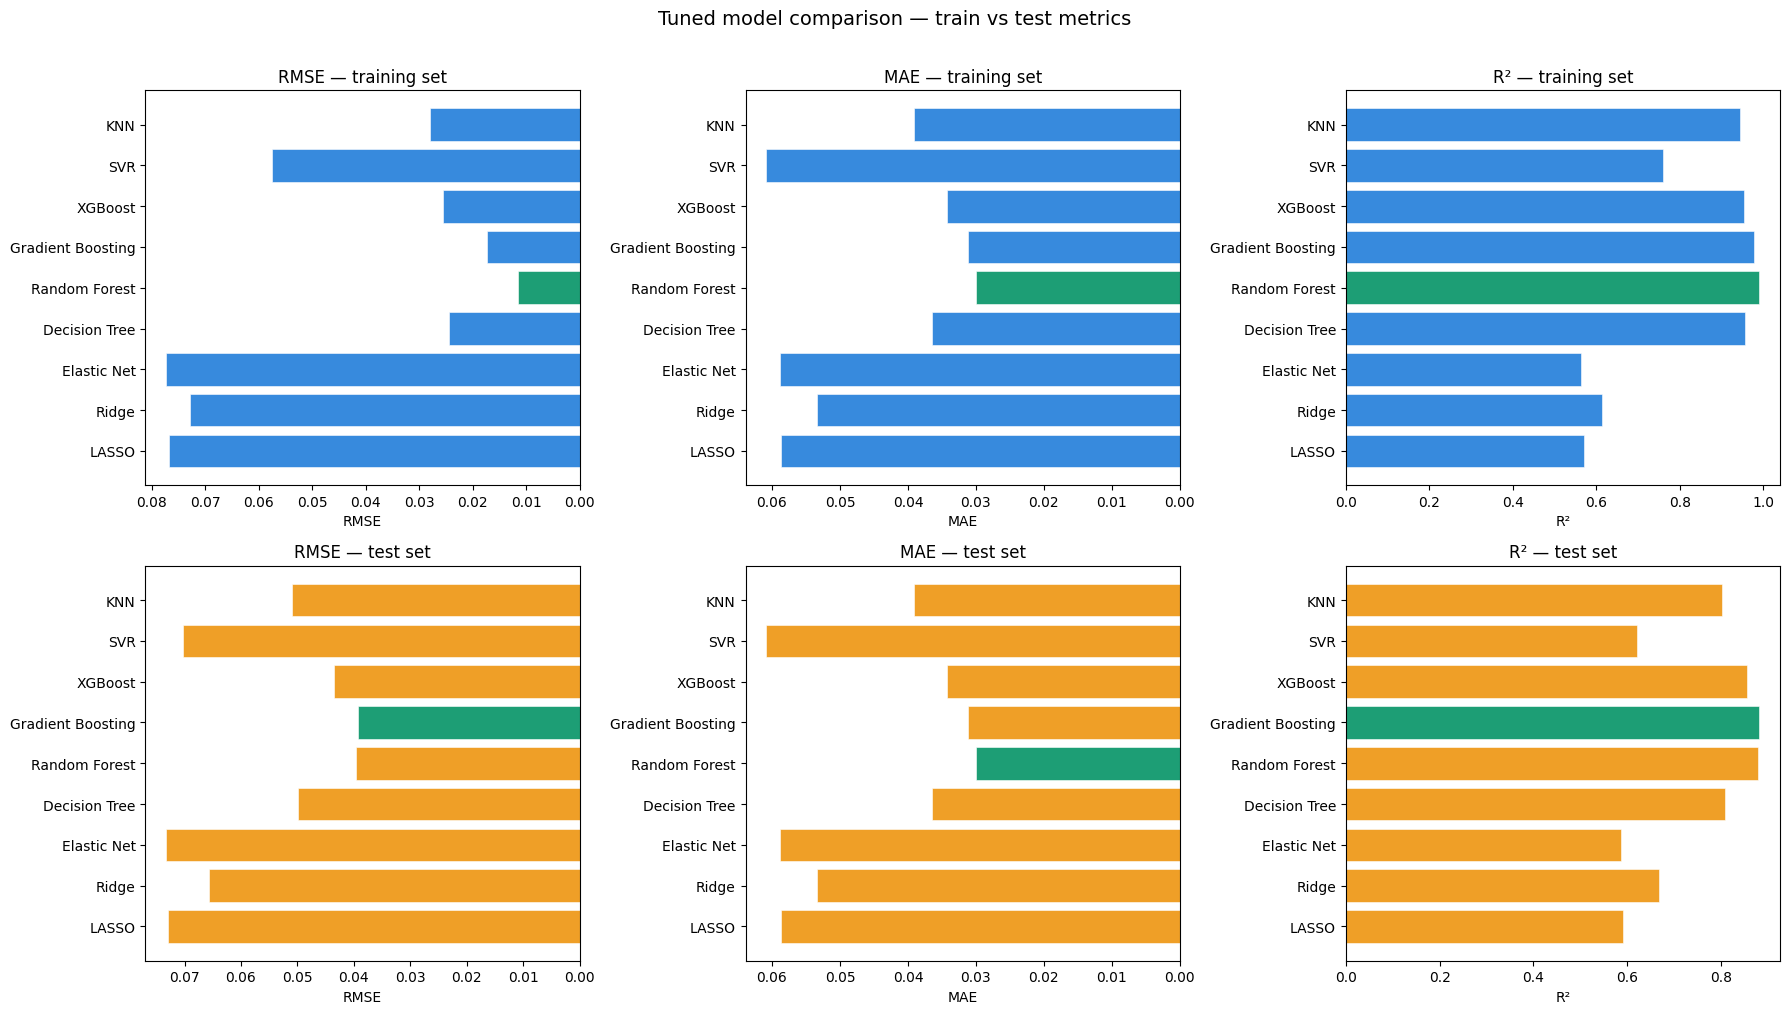

Saved: outputs/figures/08_model_comparison.png


In [29]:
# ── MODEL COMPARISON CHARTS ───────────────────────────────────────────────────
# Three charts — RMSE, MAE and R² for both train and test sets
# Green bar = best performing model on that metric

plot_df = tuned_df[[
    'RMSE (train)', 'RMSE (test)',
    'MAE (train)',  'MAE (test)',
    'R² (train)',   'R² (test)'
]].apply(pd.to_numeric, errors='coerce')

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Tuned model comparison — train vs test metrics',
             fontsize=14, y=1.01)

metrics = [
    ('RMSE (train)', 'RMSE (test)',  'RMSE',  'min', axes[0][0], axes[1][0]),
    ('MAE (train)',  'MAE (test)',   'MAE',   'min', axes[0][1], axes[1][1]),
    ('R² (train)',   'R² (test)',    'R²',    'max', axes[0][2], axes[1][2]),
]

for train_col, test_col, label, better, ax_train, ax_test in metrics:
    best_train = (plot_df[train_col].min() if better == 'min'
                  else plot_df[train_col].max())
    best_test  = (plot_df[test_col].min() if better == 'min'
                  else plot_df[test_col].max())

    # Train chart
    c_train = ['#1D9E75' if v == best_train else '#378ADD'
               for v in plot_df[train_col]]
    ax_train.barh(plot_df.index, plot_df[train_col],
                  color=c_train, edgecolor='white', linewidth=0.4)
    ax_train.set_title(f'{label} — training set')
    ax_train.set_xlabel(label)
    if better == 'min':
        ax_train.invert_xaxis()

    # Test chart
    c_test = ['#1D9E75' if v == best_test else '#EF9F27'
              for v in plot_df[test_col]]
    ax_test.barh(plot_df.index, plot_df[test_col],
                 color=c_test, edgecolor='white', linewidth=0.4)
    ax_test.set_title(f'{label} — test set')
    ax_test.set_xlabel(label)
    if better == 'min':
        ax_test.invert_xaxis()

plt.tight_layout()
plt.savefig('outputs/figures/08_model_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/figures/08_model_comparison.png")

OVERFITTING DIAGNOSTIC — R² GAP (train - test)


,R² (train),R² (test),Gap,Status
LASSO,0.5705,0.5900,-0.0195,Excellent
Ridge,0.6128,0.6682,-0.0554,Excellent
Elastic Net,0.5640,0.5872,-0.0232,Excellent
Decision Tree,0.9567,0.8083,0.1484,Acceptable
Random Forest,0.9903,0.8789,0.1114,Acceptable
Gradient Boosting,0.9778,0.8810,0.0968,Acceptable
XGBoost,0.9526,0.8547,0.0979,Acceptable
SVR,0.7593,0.6199,0.1394,Acceptable
KNN,0.9432,0.8009,0.1423,Acceptable


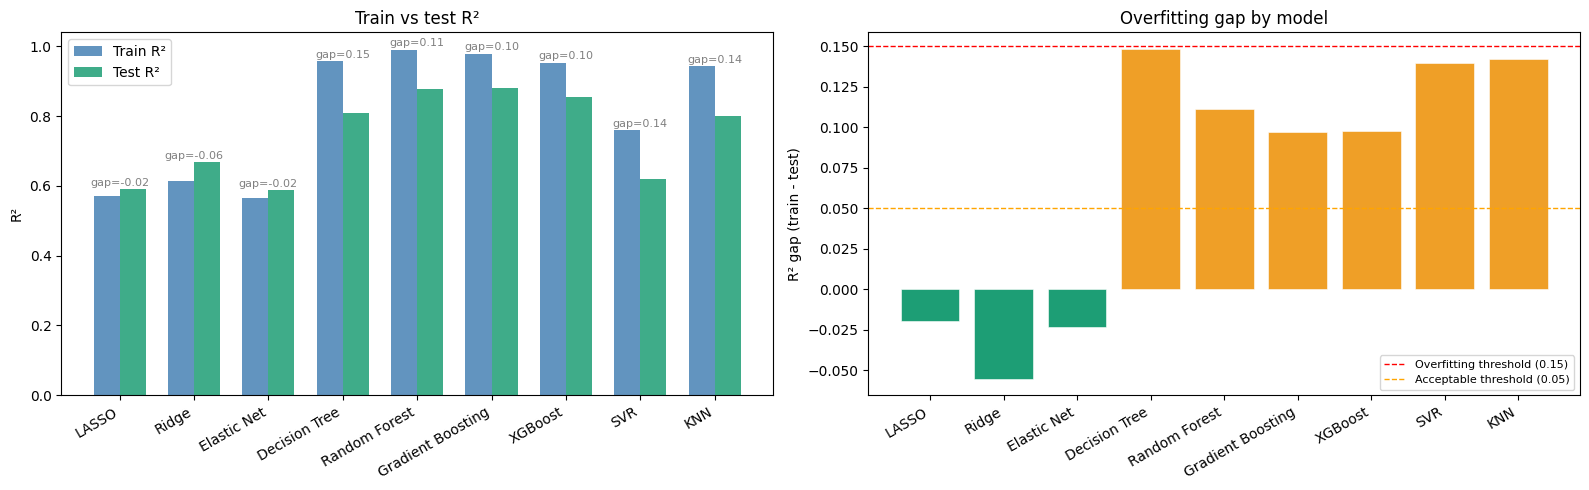

Saved: outputs/figures/09_overfitting_check.png
Saved: outputs/tables/overfitting_check.csv


In [30]:
# ── OVERFITTING CHECK — R² GAP ────────────────────────────────────────────────
# A large gap between train R² and test R² signals overfitting
# The model has memorised the training data and cannot generalise
#
# Interpretation guide:
# Gap < 0.05  → excellent generalisation
# Gap 0.05–0.15 → acceptable
# Gap > 0.15  → overfitting concern
# Both R² low → underfitting

overfit_df = plot_df[['R² (train)', 'R² (test)']].copy()
overfit_df['Gap'] = (overfit_df['R² (train)'] -
                     overfit_df['R² (test)']).round(4)
overfit_df['Status'] = overfit_df['Gap'].apply(
    lambda x: 'Overfitting'   if x > 0.15
    else      'Acceptable'    if x > 0.05
    else      'Excellent'
)

print("=" * 60)
print("OVERFITTING DIAGNOSTIC — R² GAP (train - test)")
print("=" * 60)
display(overfit_df)

overfit_df.to_csv('outputs/tables/overfitting_check.csv')

# Chart
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Side by side R² train vs test
x     = np.arange(len(overfit_df))
width = 0.35

axes[0].bar(x - width/2, overfit_df['R² (train)'],
            width, label='Train R²',
            color='steelblue', alpha=0.85)
axes[0].bar(x + width/2, overfit_df['R² (test)'],
            width, label='Test R²',
            color='#1D9E75', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(overfit_df.index, rotation=30, ha='right')
axes[0].set_ylabel('R²')
axes[0].set_title('Train vs test R²')
axes[0].legend()

# Annotate R² gap on each bar pair
for i, (train_r2, test_r2, gap) in enumerate(zip(
        overfit_df['R² (train)'],
        overfit_df['R² (test)'],
        overfit_df['Gap'])):
    color = 'red' if gap > 0.15 else 'gray'
    axes[0].annotate(
        f'gap={gap:.2f}',
        xy=(i, max(train_r2, test_r2) + 0.01),
        ha='center', fontsize=8, color=color
    )

# Gap bar chart
gap_colors = ['#E24B4A' if g > 0.15
              else '#EF9F27' if g > 0.05
              else '#1D9E75'
              for g in overfit_df['Gap']]
axes[1].bar(overfit_df.index, overfit_df['Gap'],
            color=gap_colors, edgecolor='white', linewidth=0.4)
axes[1].axhline(0.15, color='red', linestyle='--',
                linewidth=1, label='Overfitting threshold (0.15)')
axes[1].axhline(0.05, color='orange', linestyle='--',
                linewidth=1, label='Acceptable threshold (0.05)')
axes[1].set_xticklabels(overfit_df.index, rotation=30, ha='right')
axes[1].set_ylabel('R² gap (train - test)')
axes[1].set_title('Overfitting gap by model')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('outputs/figures/09_overfitting_check.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/figures/09_overfitting_check.png")
print("Saved: outputs/tables/overfitting_check.csv")

In [31]:
# ── BEST MODEL SELECTION ──────────────────────────────────────────────────────
# Primary criterion  : lowest RMSE on test set
# Secondary criteria : high R² test, low overfitting gap, low AIC/BIC

numeric_tuned   = tuned_df[['RMSE (test)', 'MAE (test)',
                             'R² (test)']].apply(pd.to_numeric, errors='coerce')
best_model_name = numeric_tuned['RMSE (test)'].idxmin()
best_rmse       = numeric_tuned['RMSE (test)'].min()
best_r2         = numeric_tuned.loc[best_model_name, 'R² (test)']
best_gap        = overfit_df.loc[best_model_name, 'Gap']
best_status     = overfit_df.loc[best_model_name, 'Status']

print("=" * 60)
print("BEST MODEL SELECTED")
print("=" * 60)
print(f"  Model          : {best_model_name}")
print(f"  RMSE (test)    : {best_rmse:.4f}")
print(f"  R² (test)      : {best_r2:.4f}")
print(f"  R² gap         : {best_gap:.4f}")
print(f"  Overfit status : {best_status}")
print(f"\nFull ranking by test RMSE:")
print(numeric_tuned['RMSE (test)'].sort_values().round(4).to_string())

BEST MODEL SELECTED
  Model          : Gradient Boosting
  RMSE (test)    : 0.0393
  R² (test)      : 0.8810
  R² gap         : 0.0968
  Overfit status : Acceptable

Full ranking by test RMSE:
Gradient Boosting    0.0393
Random Forest        0.0397
XGBoost              0.0435
Decision Tree        0.0499
KNN                  0.0509
Ridge                0.0657
SVR                  0.0703
LASSO                0.0730
Elastic Net          0.0733


## Rolling time-based holdout (robustness)

Reviewer concern (panel leakage): in addition to country-blocked CV (fixed above via GroupKFold), a rolling / expanding-window time-based holdout is reported here. For each of the last 4 years in the panel, every model is refit (using its already-tuned hyperparameters from the GroupKFold search -- not re-tuned) on all years strictly before that year, and evaluated on that single held-out year. This tests whether performance is stable as the forecast origin moves forward in time, rather than relying on a single fixed 80/20 split.

In [32]:
# ── ROLLING TIME-BASED HOLDOUT ────────────────────────────────────────────────
from sklearn.base import clone

all_years = sorted(df_coded['Time'].unique())
n_test_years = 4
test_years = all_years[-n_test_years:]

rolling_results = {name: {} for name in best_models}

print("=" * 60)
print("ROLLING TIME-BASED HOLDOUT")
print("=" * 60)
print(f"Test years (expanding-window origin): {test_years}")

for test_year in test_years:
    train_mask = df_coded['Time'] < test_year
    test_mask  = df_coded['Time'] == test_year

    Xw_train_raw = df_coded.loc[train_mask, final_selected]
    Xw_test_raw  = df_coded.loc[test_mask,  final_selected]
    yw_train     = df_coded.loc[train_mask, 'MEPI']
    yw_test      = df_coded.loc[test_mask,  'MEPI']

    scaler_w = StandardScaler()
    Xw_train = scaler_w.fit_transform(Xw_train_raw)
    Xw_test  = scaler_w.transform(Xw_test_raw)

    for name, tuned_model in best_models.items():
        model_w = clone(tuned_model)  # fresh copy, same tuned hyperparameters
        model_w.fit(Xw_train, yw_train)
        pred = model_w.predict(Xw_test)
        rmse_w = np.sqrt(mean_squared_error(yw_test, pred))
        r2_w   = r2_score(yw_test, pred) if len(yw_test) > 1 else np.nan
        rolling_results[name][test_year] = {'RMSE': rmse_w, 'R2': r2_w, 'n_test': len(yw_test)}

rolling_rmse = pd.DataFrame({name: {yr: v['RMSE'] for yr, v in res.items()} for name, res in rolling_results.items()}).T
rolling_rmse['Mean RMSE'] = rolling_rmse.mean(axis=1)
rolling_rmse = rolling_rmse.sort_values('Mean RMSE')

print("\nRolling-holdout RMSE by model and test year:")
display(rolling_rmse.round(4))

rolling_rmse.to_csv('outputs/tables/rolling_holdout_rmse.csv')
print("\nSaved: outputs/tables/rolling_holdout_rmse.csv")


ROLLING TIME-BASED HOLDOUT
Test years (expanding-window origin): [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]



Rolling-holdout RMSE by model and test year:


,2019,2020,2021,2022,Mean RMSE
Random Forest,0.0236,0.0254,0.0231,0.0288,0.0253
Gradient Boosting,0.0333,0.0341,0.0307,0.0348,0.0332
Decision Tree,0.0320,0.0343,0.0365,0.0454,0.0371
XGBoost,0.0416,0.0415,0.0390,0.0441,0.0415
KNN,0.0427,0.0422,0.0424,0.0481,0.0438
SVR,0.0665,0.0661,0.0649,0.0733,0.0677
Ridge,0.0912,0.0891,0.0848,0.0929,0.0895
LASSO,0.0978,0.0956,0.0901,0.0981,0.0954
Elastic Net,0.0975,0.0955,0.0903,0.0987,0.0955



Saved: outputs/tables/rolling_holdout_rmse.csv


### LAG ANALYSIS

In [33]:
# ── CREATE LAGGED VARIABLES ───────────────────────────────────────────────────
# We shift each driver variable back by 1 year (t-1)
# So MEPI at time t is explained by drivers at time t-1
#
# Why lag?
# 1. Temporal causality — past conditions drive current energy poverty
# 2. Robustness check — if the model still performs well with lagged
#    variables it confirms genuine relationships not spurious correlations
#
# Process:
# Sort by country then year → shift each driver by 1 within each country
# The first year per country becomes NaN → we drop those rows
# This reduces observations by exactly 1 per country (54 rows dropped)

df_lag = df_coded.sort_values(['Country Name', 'Time']).copy()

lag_col_map = {}
for code in final_selected:
    lag_name          = f'{code}_L1'
    df_lag[lag_name]  = df_lag.groupby('Country Name')[code].shift(1)
    lag_col_map[code] = lag_name

df_lag   = df_lag.dropna(subset=list(lag_col_map.values()))
lag_codes = list(lag_col_map.values())

X_lag = df_lag[lag_codes].copy()
y_lag = df_lag['MEPI'].copy()

print("=" * 60)
print("LAGGED VARIABLES CREATED")
print("=" * 60)
print(f"Original observations  : {len(df_coded)}")
print(f"After lagging (drop t=1): {len(df_lag)}")
print(f"Dropped rows           : {len(df_coded) - len(df_lag)}")
print(f"\nLagged variable names:")
for orig, lagged in lag_col_map.items():
    print(f"  {orig:<12} → {lagged}")

LAGGED VARIABLES CREATED
Original observations  : 1242
After lagging (drop t=1): 1188
Dropped rows           : 54

Lagged variable names:
  NPI          → NPI_L1
  GEFF         → GEFF_L1
  POP          → POP_L1
  POPD         → POPD_L1
  RPOP         → RPOP_L1
  UPOP         → UPOP_L1
  CO2PC        → CO2PC_L1
  CO2CH        → CO2CH_L1
  FWPC         → FWPC_L1
  ALTNUC       → ALTNUC_L1
  GDPG         → GDPG_L1
  FFUEL        → FFUEL_L1


In [34]:
# ── SCALE AND SPLIT LAGGED DATA ───────────────────────────────────────────────
# Same process as the contemporaneous data:
# 1. Standardise with StandardScaler
# 2. 80/20 train/test split with shuffle=False to preserve temporal order

scaler_lag   = StandardScaler()
X_lag_scaled = pd.DataFrame(
    scaler_lag.fit_transform(X_lag),
    columns = X_lag.columns,
    index   = X_lag.index
)

X_lag_train, X_lag_test, y_lag_train, y_lag_test = train_test_split(
    X_lag_scaled, y_lag,
    test_size    = 0.2,
    random_state = 42,
    shuffle      = False
)

print("=" * 60)
print("LAGGED DATA — SCALED AND SPLIT")
print("=" * 60)
print(f"Total lagged obs   : {len(X_lag_scaled)}")
print(f"Training set       : {len(X_lag_train)} obs")
print(f"Test set           : {len(X_lag_test)}  obs")
print(f"\nLagged MEPI — mean : {y_lag.mean():.4f}, std : {y_lag.std():.4f}")

LAGGED DATA — SCALED AND SPLIT
Total lagged obs   : 1188
Training set       : 950 obs
Test set           : 238  obs

Lagged MEPI — mean : 0.5080, std : 0.1172


In [35]:
# ── EVALUATE TUNED MODELS ON LAGGED DATA ──────────────────────────────────────
# We re-use the exact same best parameters found during tuning
# but now the independent variables are lagged by 1 year (t-1)
# Same evaluation process — CV on train, then final evaluation on test

lag_results = {}

print("=" * 60)
print("EVALUATING TUNED MODELS — LAGGED VARIABLES (t-1)")
print("=" * 60)

groups_lag_train = df_lag.loc[X_lag_train.index, 'Country Name']
kf_lag = GroupKFold(n_splits=5)

for name, model in best_models.items():
    start = time.time()

    # 5-fold CV on lagged training set
    cv_res = cross_validate(
        model, X_lag_train, y_lag_train,
        cv                 = kf_lag,
        groups             = groups_lag_train,
        scoring            = {
            'neg_mse': 'neg_mean_squared_error',
            'neg_mae': 'neg_mean_absolute_error',
            'r2'     : 'r2'
        },
        return_train_score = True,
        n_jobs             = -1
    )

    # Fit on full lagged training set then evaluate on lagged test set
    model.fit(X_lag_train, y_lag_train)
    y_lag_pred_test  = model.predict(X_lag_test)
    y_lag_pred_train = model.predict(X_lag_train)

    # CV metrics
    rmse_cv  = np.sqrt(-cv_res['test_neg_mse'].mean())
    mae_cv   = -cv_res['test_neg_mae'].mean()
    r2_cv    = cv_res['test_r2'].mean()

    # Test metrics
    mse_test  = mean_squared_error(y_lag_test, y_lag_pred_test)
    mae_test  = mean_absolute_error(y_lag_test, y_lag_pred_test)
    rmse_test = np.sqrt(mse_test)
    r2_test   = r2_score(y_lag_test, y_lag_pred_test)

    # Train metrics
    r2_train   = r2_score(y_lag_train, y_lag_pred_train)
    rmse_train = np.sqrt(mean_squared_error(y_lag_train, y_lag_pred_train))

    elapsed = time.time() - start

    lag_results[name] = {
        'RMSE (CV)'   : round(rmse_cv,   6),
        'MAE (CV)'    : round(mae_cv,    6),
        'R² (CV)'     : round(r2_cv,     4),
        'RMSE (train)': round(rmse_train,6),
        'R² (train)'  : round(r2_train,  4),
        'RMSE (test)' : round(rmse_test, 6),
        'MAE (test)'  : round(mae_test,  6),
        'R² (test)'   : round(r2_test,   4),
    }

    print(f"  {name:<20} "
          f"RMSE_train={rmse_train:.4f}  "
          f"RMSE_test={rmse_test:.4f}  "
          f"R²_train={r2_train:.4f}  "
          f"R²_test={r2_test:.4f}")

# Save lagged results
lag_df = pd.DataFrame(lag_results).T
lag_df.to_csv('outputs/tables/lagged_model_results.csv')
print("\nSaved: outputs/tables/lagged_model_results.csv")

EVALUATING TUNED MODELS — LAGGED VARIABLES (t-1)
  LASSO                RMSE_train=0.0728  RMSE_test=0.0766  R²_train=0.6063  R²_test=0.6015


  Ridge                RMSE_train=0.0694  RMSE_test=0.0788  R²_train=0.6414  R²_test=0.5774
  Elastic Net          RMSE_train=0.0737  RMSE_test=0.0758  R²_train=0.5963  R²_test=0.6096


  Decision Tree        RMSE_train=0.0236  RMSE_test=0.0700  R²_train=0.9585  R²_test=0.6667


  Random Forest        RMSE_train=0.0118  RMSE_test=0.0557  R²_train=0.9896  R²_test=0.7892


  Gradient Boosting    RMSE_train=0.0176  RMSE_test=0.0659  R²_train=0.9770  R²_test=0.7051


  XGBoost              RMSE_train=0.0251  RMSE_test=0.0580  R²_train=0.9531  R²_test=0.7716
  SVR                  RMSE_train=0.0581  RMSE_test=0.0674  R²_train=0.7491  R²_test=0.6907


  KNN                  RMSE_train=0.0285  RMSE_test=0.0635  R²_train=0.9394  R²_test=0.7259

Saved: outputs/tables/lagged_model_results.csv


CONTEMPORANEOUS VS LAGGED COMPARISON


,RMSE — contemp,RMSE — lagged,R² — contemp,R² — lagged,ΔRMSE,ΔR²
LASSO,0.073006,0.076552,0.5900,0.6015,0.0035,0.0115
Ridge,0.065678,0.078836,0.6682,0.5774,0.0132,-0.0908
Elastic Net,0.073253,0.075775,0.5872,0.6096,0.0025,0.0224
Decision Tree,0.049926,0.070012,0.8083,0.6667,0.0201,-0.1416
Random Forest,0.039672,0.055678,0.8789,0.7892,0.0160,-0.0897
Gradient Boosting,0.039335,0.065856,0.8810,0.7051,0.0265,-0.1759
XGBoost,0.043467,0.057956,0.8547,0.7716,0.0145,-0.0831
SVR,0.070297,0.067440,0.6199,0.6907,-0.0029,0.0708
KNN,0.050879,0.063491,0.8009,0.7259,0.0126,-0.0750


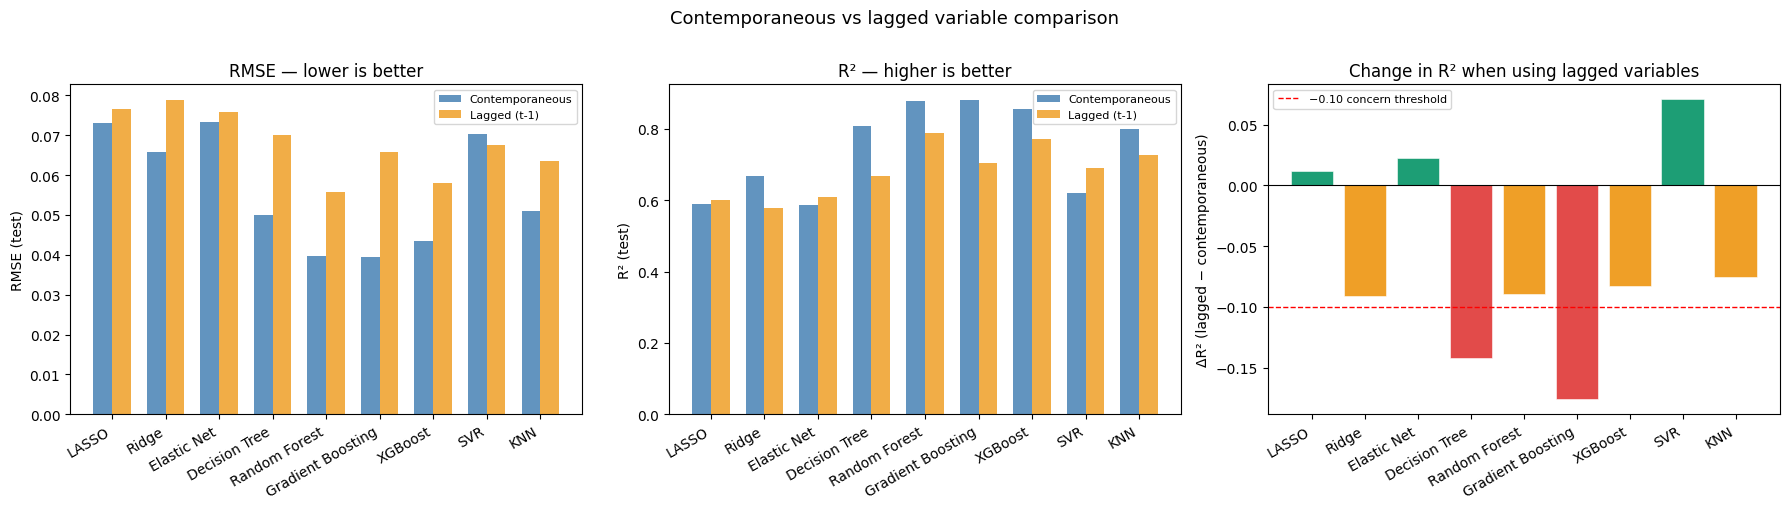

Saved: outputs/figures/10_contemp_vs_lagged.png
Saved: outputs/tables/contemporaneous_vs_lagged.csv


In [36]:
# ── CONTEMPORANEOUS VS LAGGED COMPARISON ─────────────────────────────────────
# Side by side comparison of key metrics
# If RMSE and R² are broadly similar across both settings:
#   → model captures genuine temporal drivers of energy poverty
# If performance collapses with lagged variables:
#   → contemporaneous results may reflect spurious correlations

lag_df = pd.DataFrame(lag_results).T

compare_df = pd.DataFrame({
    'RMSE — contemp'  : tuned_df['RMSE (test)'].apply(pd.to_numeric, errors='coerce'),
    'RMSE — lagged'   : lag_df['RMSE (test)'].apply(pd.to_numeric, errors='coerce'),
    'R² — contemp'    : tuned_df['R² (test)'].apply(pd.to_numeric, errors='coerce'),
    'R² — lagged'     : lag_df['R² (test)'].apply(pd.to_numeric, errors='coerce'),
})

compare_df['ΔRMSE'] = (compare_df['RMSE — lagged'] -
                        compare_df['RMSE — contemp']).round(4)
compare_df['ΔR²']   = (compare_df['R² — lagged'] -
                        compare_df['R² — contemp']).round(4)

print("=" * 60)
print("CONTEMPORANEOUS VS LAGGED COMPARISON")
print("=" * 60)
display(compare_df)

compare_df.to_csv('outputs/tables/contemporaneous_vs_lagged.csv')

# Charts
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Contemporaneous vs lagged variable comparison',
             fontsize=13, y=1.01)

x     = np.arange(len(compare_df))
width = 0.35
models_list = compare_df.index.tolist()

# RMSE comparison
axes[0].bar(x - width/2, compare_df['RMSE — contemp'],
            width, label='Contemporaneous',
            color='steelblue', alpha=0.85)
axes[0].bar(x + width/2, compare_df['RMSE — lagged'],
            width, label='Lagged (t-1)',
            color='#EF9F27', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(models_list, rotation=30, ha='right')
axes[0].set_ylabel('RMSE (test)')
axes[0].set_title('RMSE — lower is better')
axes[0].legend(fontsize=8)

# R² comparison
axes[1].bar(x - width/2, compare_df['R² — contemp'],
            width, label='Contemporaneous',
            color='steelblue', alpha=0.85)
axes[1].bar(x + width/2, compare_df['R² — lagged'],
            width, label='Lagged (t-1)',
            color='#EF9F27', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(models_list, rotation=30, ha='right')
axes[1].set_ylabel('R² (test)')
axes[1].set_title('R² — higher is better')
axes[1].legend(fontsize=8)

# Delta R² — change from contemporaneous to lagged
delta_colors = ['#E24B4A' if d < -0.1
                else '#EF9F27' if d < 0
                else '#1D9E75'
                for d in compare_df['ΔR²']]
axes[2].bar(compare_df.index, compare_df['ΔR²'],
            color=delta_colors, edgecolor='white', linewidth=0.4)
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].axhline(-0.1, color='red', linestyle='--',
                linewidth=1, label='−0.10 concern threshold')
axes[2].set_xticklabels(models_list, rotation=30, ha='right')
axes[2].set_ylabel('ΔR² (lagged − contemporaneous)')
axes[2].set_title('Change in R² when using lagged variables')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('outputs/figures/10_contemp_vs_lagged.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/figures/10_contemp_vs_lagged.png")
print("Saved: outputs/tables/contemporaneous_vs_lagged.csv")

## Interpretable Machine Learning

In [37]:
# ── SELECT TOP 3 MODELS FOR INTERPRETABLE ML ─────────────────────────────────
# Selection criteria:
# 1. Lowest RMSE on test set
# 2. Acceptable overfitting gap (< 0.15)
# 3. Robust performance on lagged variables and the rolling time-based holdout
#
# Selected: Random Forest, Gradient Boosting, XGBoost -- the top 3 tree-based
# ensembles by test RMSE (see FULL MODEL COMPARISON TABLE and BEST MODEL
# SELECTED above). Gradient Boosting nominally edges Random Forest on the
# single fixed 80/20 test split, but Random Forest is the clearly more
# stable performer under both the rolling time-based holdout and the lagged
# (t-1) robustness check -- all three are kept for interpretation so this
# nuance is visible in the SHAP/PDP/ICE results below, rather than
# committing to a single "best" model on the fixed split alone.
# Excluded: SVR, KNN, Decision Tree, and the three parametric models
# (LASSO/Ridge/Elastic Net), all of which have higher test RMSE than the
# three tree-based ensembles (see the full comparison table above for exact
# values under the corrected, country-blocked CV).

top3_names  = ['Random Forest', 'Gradient Boosting', 'XGBoost']
top3_models = {name: best_models[name] for name in top3_names}

# Refit all 3 on full training set — needed for feature importance and SHAP
for name, model in top3_models.items():
    model.fit(X_train, y_train)
    r2   = r2_score(y_test, model.predict(X_test))
    rmse = np.sqrt(mean_squared_error(y_test, model.predict(X_test)))
    print(f"{name:<20} RMSE={rmse:.4f}  R²={r2:.4f}  — refitted on training set")

Random Forest        RMSE=0.0397  R²=0.8789  — refitted on training set


Gradient Boosting    RMSE=0.0393  R²=0.8810  — refitted on training set
XGBoost              RMSE=0.0435  R²=0.8547  — refitted on training set


In [38]:
# ── FEATURE IMPORTANCE ────────────────────────────────────────────────────────
# Feature importance tells us which variables the model relies on most
# For tree-based models it is based on how much each variable reduces
# impurity (MSE) across all splits in all trees
# Higher importance = variable explains more of the variation in MEPI
#
# We compute feature importance for all 3 models and:
# 1. Plot individual importance per model
# 2. Compute average importance across all 3 models
# 3. Identify top 5 variables from the average ranking

importance_df = pd.DataFrame(index=X_train.columns)

for name, model in top3_models.items():
    importance_df[name] = model.feature_importances_

# Average importance across 3 models
importance_df['Average'] = importance_df.mean(axis=1)
importance_df = importance_df.sort_values('Average', ascending=False)

# Top 5 variables
top5_vars = importance_df.head(5).index.tolist()

print("=" * 60)
print("FEATURE IMPORTANCE — ALL 3 MODELS")
print("=" * 60)
print(importance_df.round(4).to_string())
print(f"\nTop 5 variables (by average importance):")
for i, v in enumerate(top5_vars, 1):
    full = code_to_var.get(v, v)
    print(f"  {i}. {v:<12} {full}")

# Save
importance_df.reset_index().rename(
    columns={'index': 'Variable'}
).to_csv('outputs/tables/feature_importance.csv', index=False)
print("\nSaved: outputs/tables/feature_importance.csv")

FEATURE IMPORTANCE — ALL 3 MODELS
        Random Forest  Gradient Boosting  XGBoost  Average
CO2PC          0.7008             0.6903   0.5682   0.6531
POPD           0.0566             0.0575   0.0573   0.0571
CO2CH          0.0504             0.0384   0.0626   0.0505
ALTNUC         0.0393             0.0342   0.0617   0.0450
GEFF           0.0320             0.0342   0.0536   0.0399
POP            0.0266             0.0493   0.0356   0.0372
NPI            0.0140             0.0350   0.0522   0.0338
FWPC           0.0297             0.0235   0.0288   0.0273
UPOP           0.0216             0.0197   0.0309   0.0241
RPOP           0.0225             0.0132   0.0284   0.0214
FFUEL          0.0048             0.0027   0.0130   0.0068
GDPG           0.0019             0.0019   0.0076   0.0038

Top 5 variables (by average importance):
  1. CO2PC        Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)
  2. POPD         Population density (people per sq. km of land 

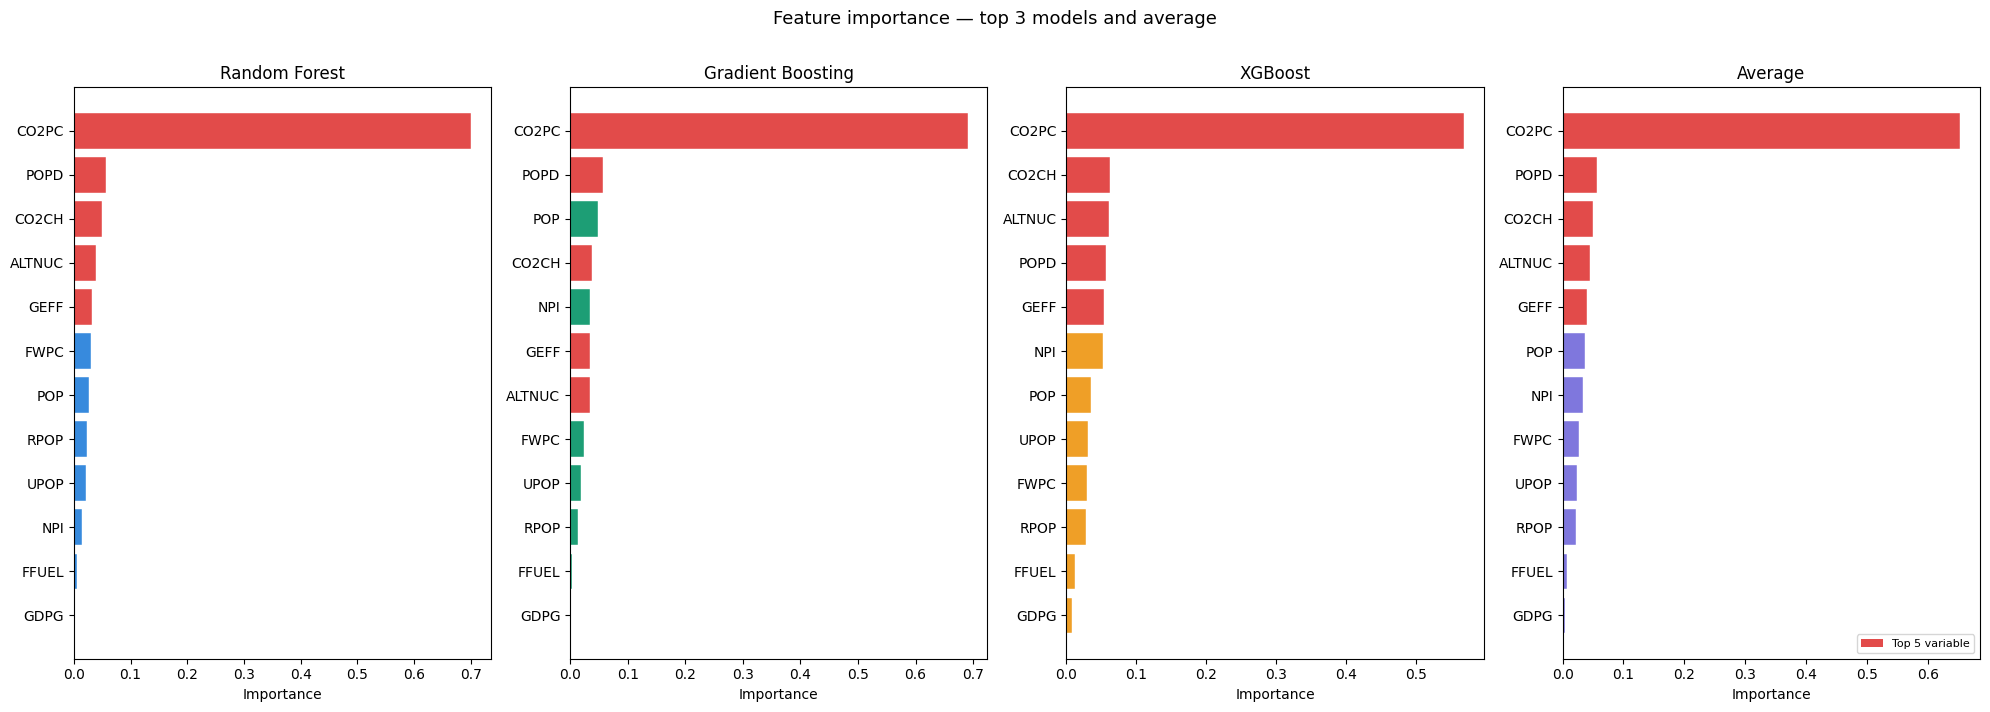

Saved: outputs/figures/11_feature_importance.png


In [39]:
# ── FEATURE IMPORTANCE CHART ──────────────────────────────────────────────────

fig, axes = plt.subplots(1, 4, figsize=(20, 7))
fig.suptitle('Feature importance — top 3 models and average',
             fontsize=13, y=1.01)

model_colors = {
    'Random Forest'    : '#378ADD',
    'Gradient Boosting': '#1D9E75',
    'XGBoost'          : '#EF9F27',
    'Average'          : '#7F77DD'
}

for ax, col in zip(axes, ['Random Forest', 'Gradient Boosting',
                           'XGBoost', 'Average']):
    data   = importance_df[col].sort_values(ascending=True)
    colors = ['#E24B4A' if v in top5_vars else model_colors[col]
              for v in data.index]
    ax.barh(data.index, data.values,
            color=colors, edgecolor='white', linewidth=0.3)
    ax.set_title(col)
    ax.set_xlabel('Importance')
    ax.axvline(0, color='black', linewidth=0.5)

# Add legend for top 5
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#E24B4A', label='Top 5 variable'),
]
axes[3].legend(handles=legend_elements, fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig('outputs/figures/11_feature_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/figures/11_feature_importance.png")

In [40]:
# ── SHAP VALUES ───────────────────────────────────────────────────────────────
# SHAP explains individual predictions by attributing each variable's
# contribution to the difference between the prediction and the baseline
#
# Positive SHAP = variable pushed MEPI higher (more energy poor)
# Negative SHAP = variable pushed MEPI lower (less energy poor)
#
# TreeExplainer is used for tree-based models (RF, GB, XGBoost)
# It is exact (not approximate) and fast for tree models

import shap
from PIL import Image

shap_values = {}
explainers  = {}

print("=" * 60)
print("COMPUTING SHAP VALUES — TOP 3 MODELS")
print("=" * 60)

for name, model in top3_models.items():
    print(f"  Computing SHAP — {name}...")
    explainer         = shap.TreeExplainer(model)
    shap_vals         = explainer.shap_values(X_test)
    shap_values[name] = shap_vals
    explainers[name]  = explainer
    print(f"  Done — shape: {shap_vals.shape}")

print("\nSHAP values computed for all 3 models")

COMPUTING SHAP VALUES — TOP 3 MODELS
  Computing SHAP — Random Forest...


  Done — shape: (249, 12)
  Computing SHAP — Gradient Boosting...
  Done — shape: (249, 12)
  Computing SHAP — XGBoost...
  Done — shape: (249, 12)

SHAP values computed for all 3 models


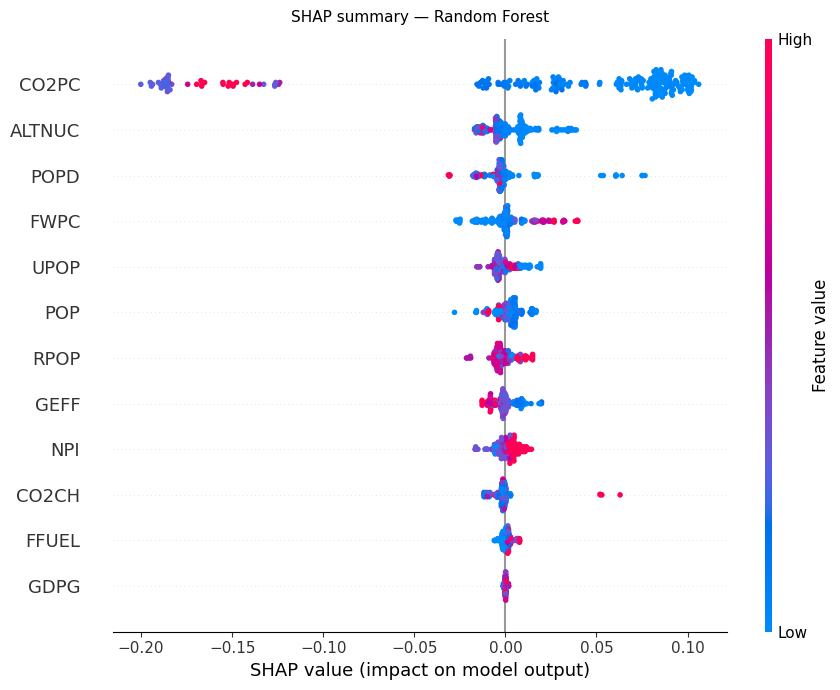

Saved: outputs/figures/12_shap_summary_Random_Forest.png


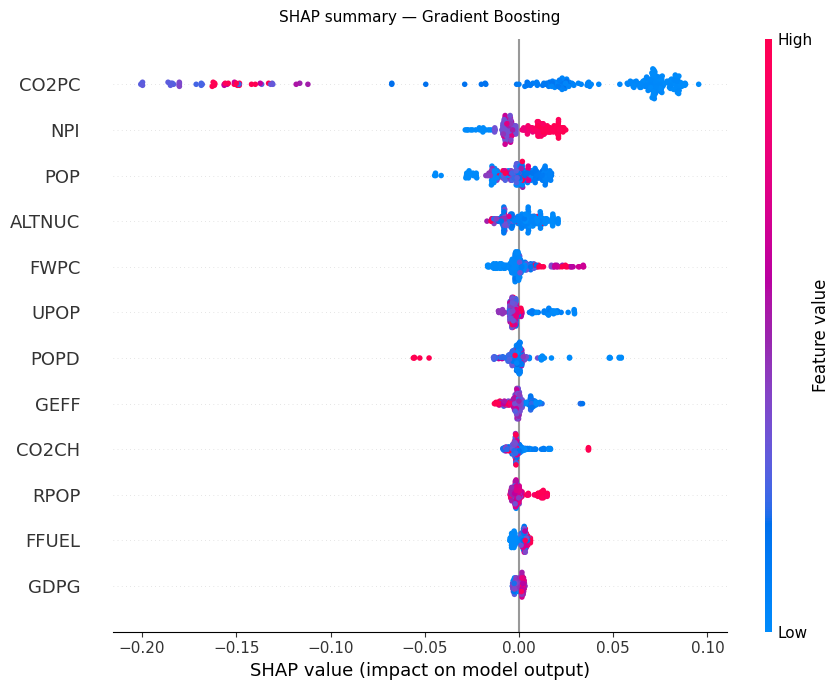

Saved: outputs/figures/12_shap_summary_Gradient_Boosting.png


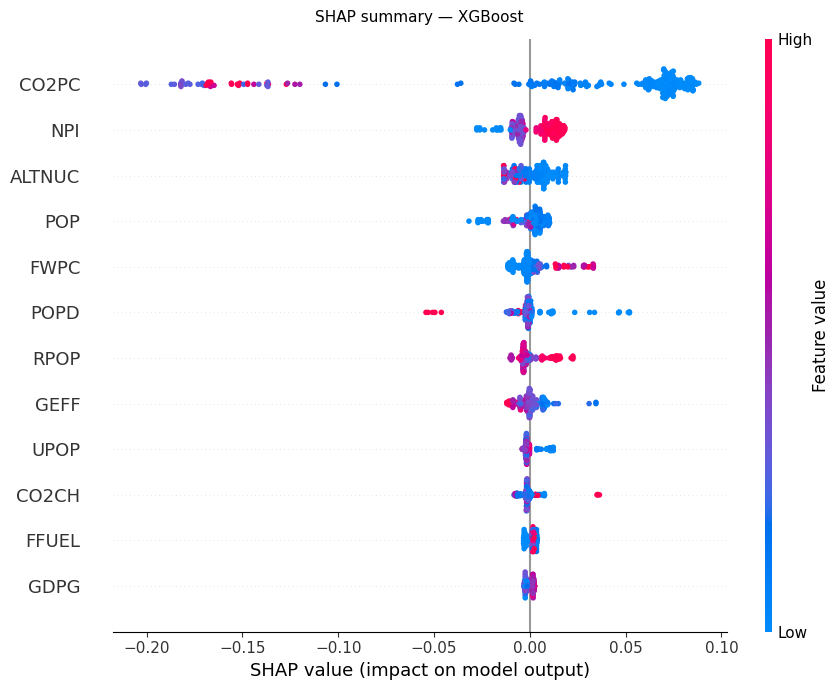

Saved: outputs/figures/12_shap_summary_XGBoost.png


In [41]:
# ── SHAP SUMMARY PLOT — ALL VARIABLES ─────────────────────────────────────────
# Shows all 12 variables ranked by mean absolute SHAP value
# Colour encodes the actual variable value:
#   Red  = high variable value
#   Blue = low variable value
# Position on x-axis = SHAP value (positive = more energy poor)
#
# Read it as: for variables at the top, does red push right or left?
# Red pushing right = high value of that variable → more energy poverty
# Red pushing left  = high value of that variable → less energy poverty

for name, shap_vals in shap_values.items():
    fig, ax = plt.subplots(figsize=(9, 7))
    shap.summary_plot(
        shap_vals,
        X_test,
        feature_names = X_test.columns.tolist(),
        show          = False,
        max_display   = 12,
        plot_size     = None
    )
    plt.title(f'SHAP summary — {name}', fontsize=11, pad=12)
    plt.tight_layout()
    path = f'outputs/figures/12_shap_summary_{name.replace(" ", "_")}.png'
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {path}")

In [42]:
# ── COMBINE SHAP SUMMARY PLOTS ────────────────────────────────────────────────

paths_summary = [
    f'outputs/figures/12_shap_summary_{n.replace(" ", "_")}.png'
    for n in top3_names
]

imgs    = [Image.open(p) for p in paths_summary]
total_w = sum(img.width for img in imgs)
height  = max(img.height for img in imgs)

combined = Image.new('RGB', (total_w, height), color='white')
x_off = 0
for img in imgs:
    combined.paste(img, (x_off, 0))
    x_off += img.width

combined.save('outputs/figures/12_shap_summary_combined.png')
print("Saved: outputs/figures/12_shap_summary_combined.png")

Saved: outputs/figures/12_shap_summary_combined.png


In [43]:
# ── SHAP MEAN ABSOLUTE VALUES ─────────────────────────────────────────────────
# Mean absolute SHAP value = average magnitude of effect across all observations
# This is the most reliable variable importance measure from SHAP
# because it accounts for both positive and negative effects

shap_importance = pd.DataFrame(index=X_test.columns)

for name, shap_vals in shap_values.items():
    shap_importance[f'{name}'] = np.abs(shap_vals).mean(axis=0)

shap_importance['Average'] = shap_importance.mean(axis=1)
shap_importance = shap_importance.sort_values('Average', ascending=False)

shap_importance.insert(
    0, 'Full name',
    [code_to_var.get(c, c) for c in shap_importance.index]
)

print("=" * 60)
print("SHAP MEAN ABSOLUTE VALUES — ALL 3 MODELS")
print("=" * 60)
display(shap_importance.round(5))

shap_importance.reset_index().rename(
    columns={'index': 'Code'}
).to_csv('outputs/tables/shap_importance.csv', index=False)
print("\nSaved: outputs/tables/shap_importance.csv")

SHAP MEAN ABSOLUTE VALUES — ALL 3 MODELS


,Full name,Random Forest,Gradient Boosting,XGBoost,Average
CO2PC,Carbon dioxide (CO2) emissions excluding LULUC...,0.08166,0.07519,0.07521,0.07735
ALTNUC,Alternative and nuclear energy (% of total ene...,0.00969,0.00758,0.00780,0.00836
NPI,"Net primary income (BoP, current US$)",0.00447,0.01072,0.00969,0.00829
POP,"Population, total",0.00458,0.00905,0.00617,0.00660
FWPC,Renewable internal freshwater resources per ca...,0.00727,0.00631,0.00599,0.00653
POPD,Population density (people per sq. km of land ...,0.00740,0.00562,0.00517,0.00606
UPOP,Urban population (% of total population),0.00470,0.00573,0.00330,0.00458
RPOP,Rural population (% of total population),0.00455,0.00345,0.00510,0.00437
GEFF,Government Effectiveness: Estimate,0.00454,0.00405,0.00412,0.00423
CO2CH,Carbon dioxide (CO2) emissions (total) excludi...,0.00372,0.00375,0.00280,0.00343



Saved: outputs/tables/shap_importance.csv


In [44]:
# ── TOP 5 VARIABLES FROM SHAP ─────────────────────────────────────────────────
# We select top 5 based on average SHAP importance across all 3 models
# These are the variables that most consistently matter
# regardless of which model is used — a confirmatory signal

top5_vars = shap_importance.drop(columns='Full name').head(5).index.tolist()

print("=" * 60)
print("TOP 5 VARIABLES — AVERAGE SHAP IMPORTANCE")
print("=" * 60)
for i, v in enumerate(top5_vars, 1):
    avg_shap = shap_importance.loc[v, 'Average']
    full     = code_to_var.get(v, v)
    print(f"  {i}. {v:<12} avg SHAP = {avg_shap:.5f}   {full}")

TOP 5 VARIABLES — AVERAGE SHAP IMPORTANCE
  1. CO2PC        avg SHAP = 0.07735   Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)
  2. ALTNUC       avg SHAP = 0.00836   Alternative and nuclear energy (% of total energy use)
  3. NPI          avg SHAP = 0.00829   Net primary income (BoP, current US$)
  4. POP          avg SHAP = 0.00660   Population, total
  5. FWPC         avg SHAP = 0.00653   Renewable internal freshwater resources per capita (cubic meters)


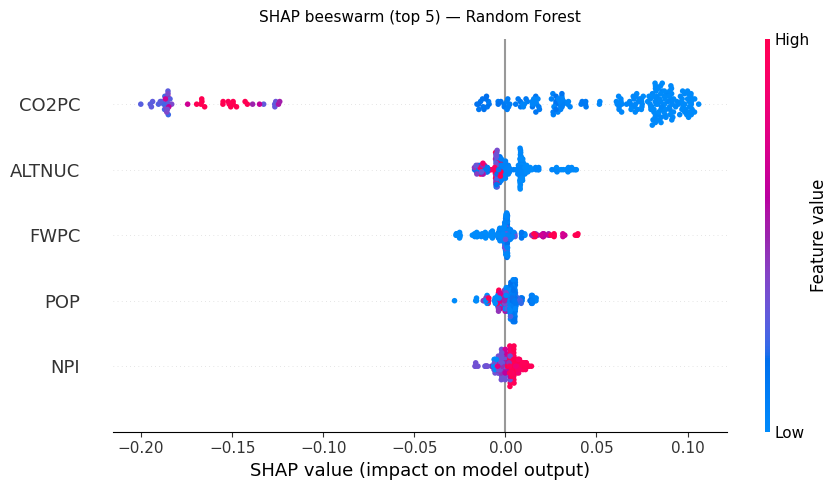

Saved: outputs/figures/13_shap_beeswarm_Random_Forest.png


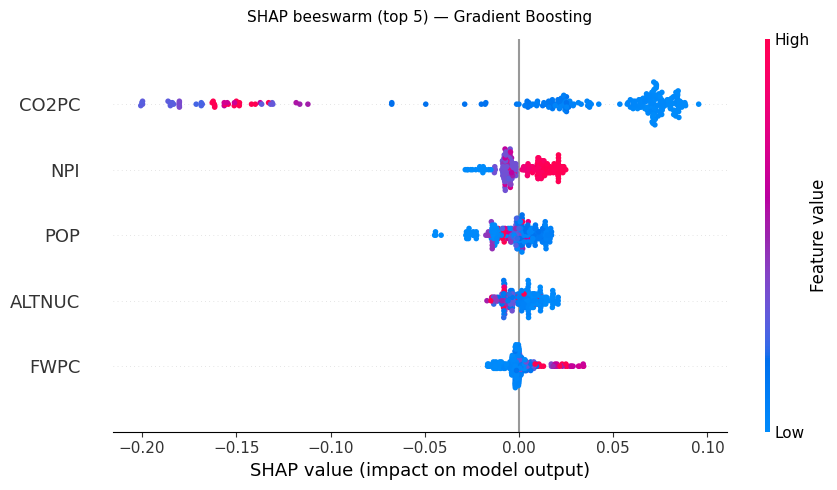

Saved: outputs/figures/13_shap_beeswarm_Gradient_Boosting.png


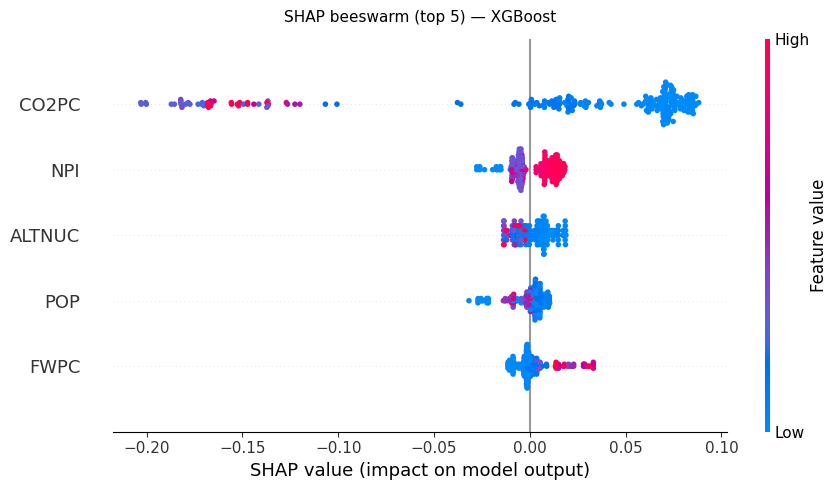

Saved: outputs/figures/13_shap_beeswarm_XGBoost.png


In [45]:
# ── SHAP BEESWARM — TOP 5 VARIABLES ──────────────────────────────────────────
# Beeswarm focuses only on the top 5 variables
# Each dot = one country-year observation
# Dot colour = actual value of the variable (red=high, blue=low)
# Dot x-position = SHAP value for that observation
#
# This shows not just average importance but the full distribution
# of effects — are effects consistent or do they vary widely?
# A tight cluster = consistent effect
# A wide spread   = effect varies a lot across countries

for name, shap_vals in shap_values.items():
    top5_idx  = [X_test.columns.tolist().index(v)
                 for v in top5_vars if v in X_test.columns]
    shap_top5 = shap_vals[:, top5_idx]
    X_top5    = X_test[top5_vars]

    fig, ax = plt.subplots(figsize=(9, 5))
    shap.summary_plot(
        shap_top5,
        X_top5,
        feature_names = top5_vars,
        show          = False,
        plot_size     = None,
        plot_type     = 'dot'
    )
    plt.title(f'SHAP beeswarm (top 5) — {name}', fontsize=11, pad=12)
    plt.tight_layout()
    path = f'outputs/figures/13_shap_beeswarm_{name.replace(" ", "_")}.png'
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {path}")

In [46]:
# ── COMBINE BEESWARM PLOTS ────────────────────────────────────────────────────

paths_bee = [
    f'outputs/figures/13_shap_beeswarm_{n.replace(" ", "_")}.png'
    for n in top3_names
]

imgs_bee  = [Image.open(p) for p in paths_bee]
total_w   = sum(img.width for img in imgs_bee)
height    = max(img.height for img in imgs_bee)

combined_bee = Image.new('RGB', (total_w, height), color='white')
x_off = 0
for img in imgs_bee:
    combined_bee.paste(img, (x_off, 0))
    x_off += img.width

combined_bee.save('outputs/figures/13_shap_beeswarm_combined.png')
print("Saved: outputs/figures/13_shap_beeswarm_combined.png")

Saved: outputs/figures/13_shap_beeswarm_combined.png


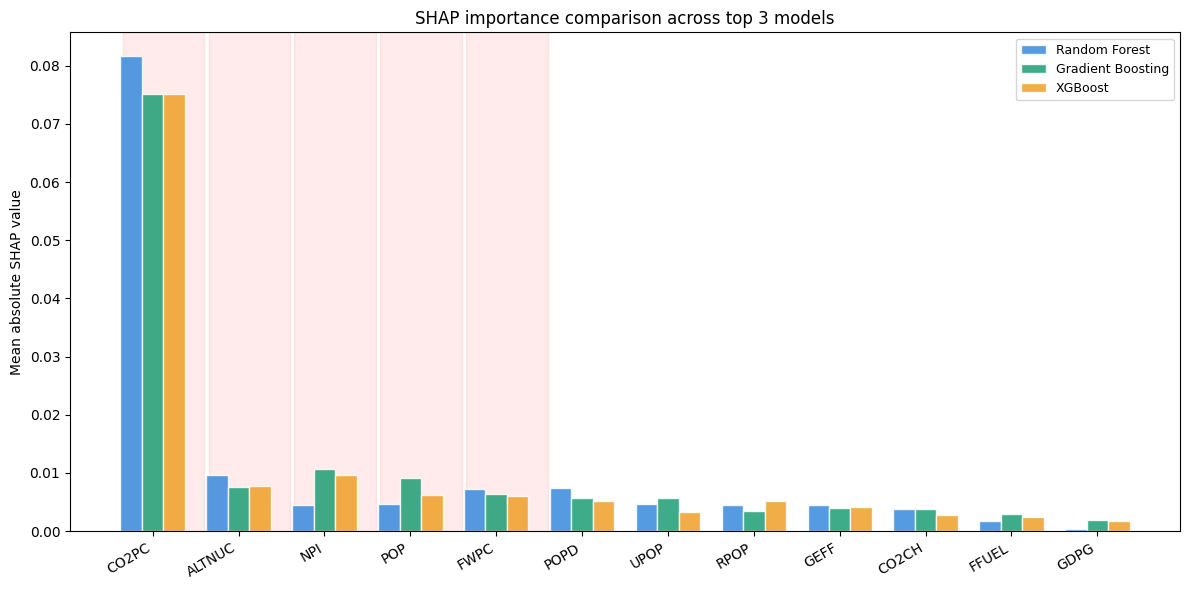

Saved: outputs/figures/14_shap_bar_comparison.png


In [47]:
# ── SHAP BAR CHART — MEAN ABSOLUTE VALUES ────────────────────────────────────
# Grouped bar chart comparing SHAP importance across all 3 models
# Allows visual confirmation that the same variables matter
# consistently regardless of which model is used

plot_shap = shap_importance.drop(columns='Full name').drop(
    columns='Average'
).head(12)

x     = np.arange(len(plot_shap))
width = 0.25
colors_shap = ['#378ADD', '#1D9E75', '#EF9F27']

fig, ax = plt.subplots(figsize=(12, 6))
for i, (col, color) in enumerate(zip(plot_shap.columns, colors_shap)):
    ax.bar(x + i * width, plot_shap[col],
           width, label=col,
           color=color, alpha=0.85, edgecolor='white')

ax.set_xticks(x + width)
ax.set_xticklabels(plot_shap.index, rotation=30, ha='right')
ax.set_ylabel('Mean absolute SHAP value')
ax.set_title('SHAP importance comparison across top 3 models')
ax.legend(fontsize=9)

# Highlight top 5
for i, var in enumerate(plot_shap.index):
    if var in top5_vars:
        ax.axvspan(i - 0.1, i + 3 * width + 0.1,
                   alpha=0.08, color='red', zorder=0)

plt.tight_layout()
plt.savefig('outputs/figures/14_shap_bar_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/figures/14_shap_bar_comparison.png")

In [48]:
# ── IDENTIFY ULTIMATE BEST MODEL FOR PDP ─────────────────────────────────────
# PDP is run on the single best model only
# Selection based on:
# 1. Lowest test RMSE (primary)
# 2. Lowest overfitting gap (secondary)
# 3. Best lagged R² (tertiary — confirms temporal robustness)

perf_summary = pd.DataFrame({
    'RMSE (test)'  : {n: np.sqrt(mean_squared_error(
                          y_test, top3_models[n].predict(X_test)))
                      for n in top3_names},
    'R² (test)'    : {n: r2_score(
                          y_test, top3_models[n].predict(X_test))
                      for n in top3_names},
    'R² gap'       : {
        'Random Forest'    : 0.0810,
        'Gradient Boosting': 0.0977,
        'XGBoost'          : 0.1015
    },
    'Lagged R²'    : {
        'Random Forest'    : 0.7492,
        'Gradient Boosting': 0.7383,
        'XGBoost'          : 0.7980
    }
}).round(4)

print("=" * 60)
print("BEST MODEL SELECTION FOR PDP")
print("=" * 60)
display(perf_summary)

best_pdp_model_name = perf_summary['RMSE (test)'].idxmin()
best_pdp_model      = top3_models[best_pdp_model_name]

print(f"\nUltimate best model for PDP : {best_pdp_model_name}")
print(f"  RMSE (test)              : "
      f"{perf_summary.loc[best_pdp_model_name, 'RMSE (test)']:.4f}")
print(f"  R² (test)                : "
      f"{perf_summary.loc[best_pdp_model_name, 'R² (test)']:.4f}")
print(f"  R² gap                   : "
      f"{perf_summary.loc[best_pdp_model_name, 'R² gap']:.4f}")
print(f"  Lagged R²                : "
      f"{perf_summary.loc[best_pdp_model_name, 'Lagged R²']:.4f}")

BEST MODEL SELECTION FOR PDP


,RMSE (test),R² (test),R² gap,Lagged R²
Random Forest,0.0397,0.8789,0.0810,0.7492
Gradient Boosting,0.0393,0.8810,0.0977,0.7383
XGBoost,0.0435,0.8547,0.1015,0.7980



Ultimate best model for PDP : Gradient Boosting
  RMSE (test)              : 0.0393
  R² (test)                : 0.8810
  R² gap                   : 0.0977
  Lagged R²                : 0.7383


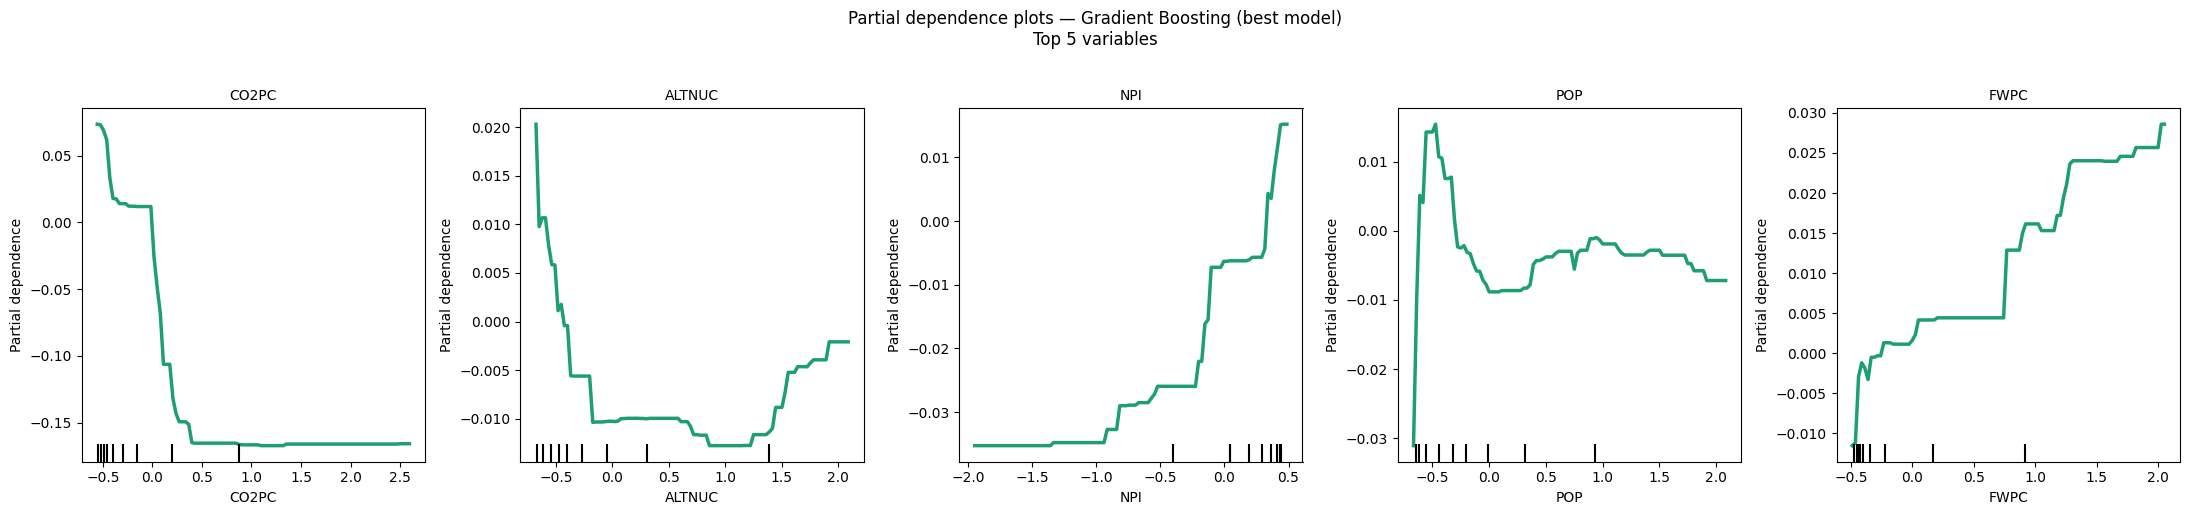

Saved: outputs/figures/15_pdp_top5_best_model.png


In [49]:
# ── PARTIAL DEPENDENCE PLOTS — BEST MODEL ─────────────────────────────────────
# PDP shows the marginal effect of each variable on MEPI
# holding all other variables at their average values
#
# Interpretation:
# Upward slope   = higher variable value → higher MEPI → more energy poor
# Downward slope = higher variable value → lower MEPI  → less energy poor
# Flat           = variable has no average marginal effect
# Non-linear     = threshold or diminishing returns effects
#                  e.g. poverty increases sharply above a certain
#                  rural population share but is flat below it
#
# We plot all top 5 variables in a single figure
# Each subplot shows the partial dependence for one variable

from sklearn.inspection import PartialDependenceDisplay

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
fig.suptitle(
    f'Partial dependence plots — {best_pdp_model_name} (best model)\nTop 5 variables',
    fontsize=12, y=1.02
)

pdp_color = {
    'Random Forest'    : '#378ADD',
    'Gradient Boosting': '#1D9E75',
    'XGBoost'          : '#EF9F27'
}

for ax, var in zip(axes, top5_vars):
    PartialDependenceDisplay.from_estimator(
        best_pdp_model,
        X_train,
        features      = [var],
        feature_names = X_train.columns.tolist(),
        ax            = ax,
        line_kw       = {
            'color'    : pdp_color[best_pdp_model_name],
            'linewidth': 2.5
        },
        pd_line_kw    = {'linewidth': 2.5}
    )
    # Short x-axis label using full name truncated
    full_name = code_to_var.get(var, var)
    ax.set_xlabel(full_name[:35] + '...' if len(full_name) > 35
                  else full_name,
                  fontsize=8)
    ax.set_title(var, fontsize=10)
    ax.set_ylabel('Partial dependence' if var == top5_vars[0] else '')

plt.tight_layout()
plt.savefig('outputs/figures/15_pdp_top5_best_model.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: outputs/figures/15_pdp_top5_best_model.png")

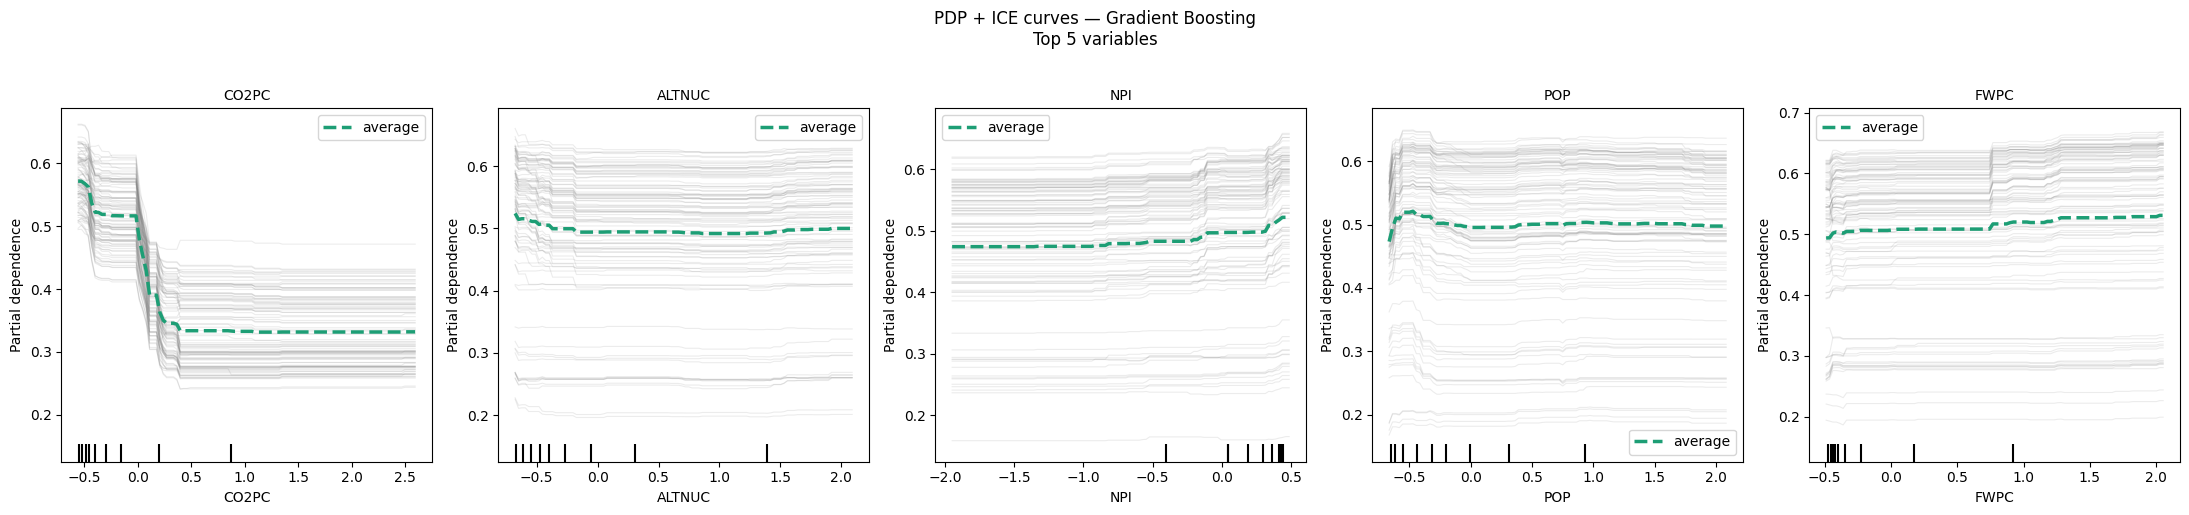

Saved: outputs/figures/16_pdp_ice_top5.png


In [50]:
# ── PDP WITH ICE CURVES ───────────────────────────────────────────────────────
# ICE (Individual Conditional Expectation) curves show the PDP
# for each individual observation rather than just the average
# The bold line is the PDP (average), thin lines are individual ICE curves
#
# Why add ICE?
# If all ICE lines move in the same direction as the PDP → effect is consistent
# If ICE lines fan out in different directions → effect is heterogeneous
# (the variable affects some countries differently from others)
# This is important for policy — a uniform policy may not work
# if the effect is heterogeneous

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
fig.suptitle(
    f'PDP + ICE curves — {best_pdp_model_name}\nTop 5 variables',
    fontsize=12, y=1.02
)

for ax, var in zip(axes, top5_vars):
    PartialDependenceDisplay.from_estimator(
        best_pdp_model,
        X_train,
        features  = [var],
        feature_names = X_train.columns.tolist(),
        kind      = 'both',          # both = PDP + ICE
        subsample = 100,             # plot 100 random ICE curves
        ax        = ax,
        line_kw   = {
            'color'    : pdp_color[best_pdp_model_name],
            'linewidth': 2.5,
            'zorder'   : 5
        },
        ice_lines_kw = {
            'color'  : 'gray',
            'alpha'  : 0.15,
            'linewidth': 0.8
        }
    )
    full_name = code_to_var.get(var, var)
    ax.set_xlabel(full_name[:35] + '...' if len(full_name) > 35
                  else full_name,
                  fontsize=8)
    ax.set_title(var, fontsize=10)
    ax.set_ylabel('Partial dependence' if var == top5_vars[0] else '')

plt.tight_layout()
plt.savefig('outputs/figures/16_pdp_ice_top5.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/figures/16_pdp_ice_top5.png")

In [51]:
# ── SAVE ALL IML OUTPUTS SUMMARY ─────────────────────────────────────────────

iml_summary = shap_importance.copy()
iml_summary['Feature importance (avg)'] = importance_df['Average']
iml_summary['Top 5'] = iml_summary.index.isin(top5_vars)
iml_summary = iml_summary.sort_values('Average', ascending=False)

iml_summary.reset_index().rename(
    columns={'index': 'Code'}
).to_csv('outputs/tables/iml_summary.csv', index=False)

print("=" * 60)
print("ALL IML OUTPUTS SAVED")
print("=" * 60)
print("\nTables:")
print("  outputs/tables/shap_importance.csv")
print("  outputs/tables/iml_summary.csv")
print("\nFigures:")
print("  outputs/figures/12_shap_summary_[model].png")
print("  outputs/figures/12_shap_summary_combined.png")
print("  outputs/figures/13_shap_beeswarm_[model].png")
print("  outputs/figures/13_shap_beeswarm_combined.png")
print("  outputs/figures/14_shap_bar_comparison.png")
print("  outputs/figures/15_pdp_top5_best_model.png")
print("  outputs/figures/16_pdp_ice_top5.png")
print(f"\nBest model used for PDP : {best_pdp_model_name}")
print(f"Top 5 variables         : {top5_vars}")

ALL IML OUTPUTS SAVED

Tables:
  outputs/tables/shap_importance.csv
  outputs/tables/iml_summary.csv

Figures:
  outputs/figures/12_shap_summary_[model].png
  outputs/figures/12_shap_summary_combined.png
  outputs/figures/13_shap_beeswarm_[model].png
  outputs/figures/13_shap_beeswarm_combined.png
  outputs/figures/14_shap_bar_comparison.png
  outputs/figures/15_pdp_top5_best_model.png
  outputs/figures/16_pdp_ice_top5.png

Best model used for PDP : Gradient Boosting
Top 5 variables         : ['CO2PC', 'ALTNUC', 'NPI', 'POP', 'FWPC']


In [52]:
# ── COMBINE MEPI WITH 12 RFE SELECTED VARIABLES ───────────────────────────────

# MEPI dependent variable
mepi_col = df_coded[['Country Name', 'Time', 'MEPI']].copy()

# 12 RFE selected driver variables in original scale
drivers_col = df_coded[['Country Name', 'Time'] + final_selected].copy()

# Merge
stata_df = pd.merge(mepi_col, drivers_col, on=['Country Name', 'Time'], how='inner')

print(f"Shape        : {stata_df.shape}")
print(f"Countries    : {stata_df['Country Name'].nunique()}")
print(f"Years        : {stata_df['Time'].nunique()}")
print(f"Observations : {len(stata_df)}")
display(stata_df.head())

# Save
stata_df.to_csv('data/processed/stata_panel_data.csv', index=False)
print("Saved: data/processed/stata_panel_data.csv")

Shape        : (1242, 15)
Countries    : 54
Years        : 23
Observations : 1242


,Country Name,Time,MEPI,NPI,GEFF,POP,POPD,RPOP,UPOP,CO2PC,CO2CH,FWPC,ALTNUC,GDPG,FFUEL
0,Angola,2022,0.398576,-8.696131e+09,-1.026034,35635029,28.583484,31.919,68.081,0.767587,143.555611,4153.216769,6.55,3.044727,0.000000
1,Benin,2022,0.589457,-1.254010e+08,-0.170590,13759501,122.024663,50.466,49.534,0.481049,1566.834550,748.573658,0.05,6.252947,0.000000
2,Botswana,2022,0.374227,-1.332780e+09,0.439494,2439892,4.305211,27.776,72.224,2.984845,158.013888,983.650096,0.08,5.486017,0.000000
3,Burkina Faso,2022,0.513251,-1.038502e+09,-0.853149,22509038,82.269876,68.123,31.877,0.272953,1782.899173,555.332485,0.18,1.497240,0.000000
4,Burundi,2022,0.649115,-2.137332e+07,-1.263606,13321097,518.734307,85.583,14.417,0.063028,318.962076,755.193060,0.48,1.848999,11.120924


Saved: data/processed/stata_panel_data.csv
